In [ ]:
!pip install scikit-learn==1.7.2

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
data = pd.read_csv('/content/drive/MyDrive/datasetProjectSleep/Impact of Digital Device Usage on Sleep Quality and Mental Healthcsv.csv')
newdata = pd.read_csv('/content/drive/MyDrive/datasetProjectSleep/แบบสำรวจการใช้มือถือส่งผลกับการนอนหรือไม่.csv')

###1.1 แสดง Shape

In [4]:
print(data.shape)
print('shape ของข้อมูล:')
print(f'จำนวนแถว: {data.shape[0]}, จำนวนคอลัมน์: {data.shape[1]} ')
print()
print(newdata.shape)
print('shape ของข้อมูล:')
print(f'จำนวนแถว: {newdata.shape[0]}, จำนวนคอลัมน์: {newdata.shape[1]} ')

(1100, 10)
shape ของข้อมูล:
จำนวนแถว: 1100, จำนวนคอลัมน์: 10 

(86, 11)
shape ของข้อมูล:
จำนวนแถว: 86, จำนวนคอลัมน์: 11 


### 1.2 แสดง Info

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Age                         1100 non-null   int64 
 1   Sleep Hours                 1100 non-null   int64 
 2   Feel Rested                 1100 non-null   object
 3   Daily Screen Time           1100 non-null   int64 
 4   Use Before Sleep            1100 non-null   object
 5   Stress Level                1100 non-null   int64 
 6   Anxiety/Low Mood            1100 non-null   object
 7   Wellness Apps               1100 non-null   object
 8   Sleep Quality               1100 non-null   object
 9   Screen Time Affects Sleep?  1100 non-null   object
dtypes: int64(4), object(6)
memory usage: 86.1+ KB


In [6]:
newdata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86 entries, 0 to 85
Data columns (total 11 columns):
 #   Column                                                             Non-Null Count  Dtype 
---  ------                                                             --------------  ----- 
 0   ประทับเวลา                                                         86 non-null     object
 1   1.คุณอายุเท่าไหร่                                                  86 non-null     object
 2   2.ระยะเวลาการนอนโดยเฉลี่ยต่อวันของคุณ (ชั่วโมง)                    86 non-null     object
 3   3.ความสดชื่นหลังตื่นนอน                                            86 non-null     object
 4   4.ระยะเวลาการใช้หน้าจอต่อวัน (ชั่วโมง)                             86 non-null     object
 5   5.คุณได้ใช้มือถือก่อนนอนหรือไม่                                    86 non-null     object
 6   6.ระดับความเครียดที่คุณรู้สึก (1 คือน้อยที่สุด - 10 คือมากที่สุด)  86 non-null     int64 
 7   7.คุณรู้สีก หงุดหงิด/วิตกกังวล เมื่อไ

###1.3 แสดง describe()

In [7]:
data.describe()

,Age,Sleep Hours,Daily Screen Time,Stress Level
count,1100.000000,1100.000000,1100.000000,1100.000000
mean,34.813636,6.911818,6.389091,5.160909
std,11.990320,1.983197,2.650986,2.317501
min,15.000000,4.000000,2.000000,1.000000
25%,24.000000,5.000000,4.000000,3.000000
50%,35.000000,7.000000,6.000000,5.000000
75%,45.000000,9.000000,8.000000,7.000000
max,55.000000,10.000000,12.000000,10.000000


In [8]:
newdata.describe()

,6.ระดับความเครียดที่คุณรู้สึก (1 คือน้อยที่สุด - 10 คือมากที่สุด)
count,86.000000
mean,5.500000
std,2.124092
min,1.000000
25%,4.000000
50%,5.000000
75%,7.000000
max,10.000000


###1.4 ตรวจสอบ Missing Values

In [9]:
print('จำนวน Missing Values แต่ละคอลัมน์:')
print(data.isnull().sum())

จำนวน Missing Values แต่ละคอลัมน์:
Age                           0
Sleep Hours                   0
Feel Rested                   0
Daily Screen Time             0
Use Before Sleep              0
Stress Level                  0
Anxiety/Low Mood              0
Wellness Apps                 0
Sleep Quality                 0
Screen Time Affects Sleep?    0
dtype: int64


In [10]:
print('จำนวน Missing Values แต่ละคอลัมน์:')
print(newdata.isnull().sum())

จำนวน Missing Values แต่ละคอลัมน์:
ประทับเวลา                                                           0
1.คุณอายุเท่าไหร่                                                    0
2.ระยะเวลาการนอนโดยเฉลี่ยต่อวันของคุณ (ชั่วโมง)                      0
3.ความสดชื่นหลังตื่นนอน                                              0
4.ระยะเวลาการใช้หน้าจอต่อวัน (ชั่วโมง)                               0
5.คุณได้ใช้มือถือก่อนนอนหรือไม่                                      0
6.ระดับความเครียดที่คุณรู้สึก (1 คือน้อยที่สุด - 10 คือมากที่สุด)    0
7.คุณรู้สีก หงุดหงิด/วิตกกังวล เมื่อไม่ได้ใช้มือถือเป็นเวลานาน       0
8.คุณได้ใช้งานแอปพลิเคชันเพื่อสุขภาพหรือไม่                          0
9.คุณภาพการนอน                                                       0
10.การใช้มือถือส่งผลต่อการนอนของคุณหรือไม่                           0
dtype: int64


In [11]:
data.head(10)

,Age,Sleep Hours,Feel Rested,Daily Screen Time,Use Before Sleep,Stress Level,Anxiety/Low Mood,Wellness Apps,Sleep Quality,Screen Time Affects Sleep?
0,47,4,Yes,11,Yes,10,No,No,Bad,Yes
1,48,4,No,8,No,7,Yes,Yes,Bad,Yes
2,40,7,Sometimes,10,No,4,No,Yes,Bad,Yes
3,26,10,Yes,5,Yes,1,Yes,No,Good,No
4,47,5,Yes,7,Yes,7,Yes,No,Good,Yes
5,51,6,No,8,Yes,7,No,No,Good,Not Sure
6,20,9,Sometimes,3,No,1,No,No,Good,No
7,21,5,Yes,9,No,7,No,No,Bad,No
8,40,8,No,5,Yes,4,Yes,No,Good,No
9,17,6,Sometimes,9,Yes,6,Yes,No,Good,Not Sure


In [12]:
data.tail(10)

,Age,Sleep Hours,Feel Rested,Daily Screen Time,Use Before Sleep,Stress Level,Anxiety/Low Mood,Wellness Apps,Sleep Quality,Screen Time Affects Sleep?
1090,21,6,Yes,6,Yes,7,Yes,No,Good,Yes
1091,15,6,Sometimes,9,No,3,Yes,No,Good,No
1092,16,10,Sometimes,4,Yes,1,Yes,Yes,Good,No
1093,21,5,Yes,8,Yes,3,No,No,Bad,Not Sure
1094,42,10,Yes,5,Yes,1,No,No,Good,No
1095,16,10,No,6,No,3,Yes,No,Good,No
1096,33,5,Sometimes,6,Yes,6,Yes,No,Bad,No
1097,30,8,No,5,Yes,2,Yes,No,Good,No
1098,31,8,Sometimes,3,Yes,1,Yes,No,Good,No
1099,17,9,Sometimes,4,Yes,5,No,No,Good,No


In [13]:
newdata.head(10)

,ประทับเวลา,1.คุณอายุเท่าไหร่,2.ระยะเวลาการนอนโดยเฉลี่ยต่อวันของคุณ (ชั่วโมง),3.ความสดชื่นหลังตื่นนอน,4.ระยะเวลาการใช้หน้าจอต่อวัน (ชั่วโมง),5.คุณได้ใช้มือถือก่อนนอนหรือไม่,6.ระดับความเครียดที่คุณรู้สึก (1 คือน้อยที่สุด - 10 คือมากที่สุด),7.คุณรู้สีก หงุดหงิด/วิตกกังวล เมื่อไม่ได้ใช้มือถือเป็นเวลานาน,8.คุณได้ใช้งานแอปพลิเคชันเพื่อสุขภาพหรือไม่,9.คุณภาพการนอน,10.การใช้มือถือส่งผลต่อการนอนของคุณหรือไม่
0,4/4/2026 21:38:58,20,3,ไม่สดชื่น,14,ใช่,5,ไม่หงุดหงิด/ไม่วิตกกังวล,ไม่ใช่,ไม่ดี,ไม่แน่ใจ
1,4/4/2026 21:39:13,20,6,ไม่สดชื่น,7,ใช่,6,ไม่หงุดหงิด/ไม่วิตกกังวล,ไม่ใช่,ดี,ใช่
2,4/4/2026 21:39:17,23,10,สดชื่น,14,ใช่,3,ไม่หงุดหงิด/ไม่วิตกกังวล,ไม่ใช่,ดี,ใช่
3,4/4/2026 21:41:24,21,6,ไม่สดชื่น,9,ใช่,7,ไม่หงุดหงิด/ไม่วิตกกังวล,ไม่ใช่,ไม่ดี,ใช่
4,4/4/2026 21:41:36,20,6,ไม่สดชื่น,16,ใช่,7,หงุดหงิด/วิตกกังวล,ใช่,ไม่ดี,ไม่ใช่
5,4/4/2026 21:41:42,21,8,ไม่สดชื่น,8,ใช่,7,หงุดหงิด/วิตกกังวล,ไม่ใช่,ดี,ใช่
6,4/4/2026 21:55:46,21,6,ไม่สดชื่น,10,ใช่,4,หงุดหงิด/วิตกกังวล,ใช่,ไม่ดี,ใช่
7,4/4/2026 22:02:41,21,3-4,ไม่สดชื่น,10+,ใช่,7,ไม่หงุดหงิด/ไม่วิตกกังวล,ไม่ใช่,ไม่ดี,ไม่แน่ใจ
8,4/4/2026 22:05:51,21,7,สดชื่น,4,ใช่,5,ไม่หงุดหงิด/ไม่วิตกกังวล,ไม่ใช่,ดี,ใช่
9,4/4/2026 22:07:04,21,5,ไม่สดชื่น,6,ใช่,5,ไม่หงุดหงิด/ไม่วิตกกังวล,ไม่ใช่,ดี,ไม่แน่ใจ


In [14]:
newdata.tail(10)

,ประทับเวลา,1.คุณอายุเท่าไหร่,2.ระยะเวลาการนอนโดยเฉลี่ยต่อวันของคุณ (ชั่วโมง),3.ความสดชื่นหลังตื่นนอน,4.ระยะเวลาการใช้หน้าจอต่อวัน (ชั่วโมง),5.คุณได้ใช้มือถือก่อนนอนหรือไม่,6.ระดับความเครียดที่คุณรู้สึก (1 คือน้อยที่สุด - 10 คือมากที่สุด),7.คุณรู้สีก หงุดหงิด/วิตกกังวล เมื่อไม่ได้ใช้มือถือเป็นเวลานาน,8.คุณได้ใช้งานแอปพลิเคชันเพื่อสุขภาพหรือไม่,9.คุณภาพการนอน,10.การใช้มือถือส่งผลต่อการนอนของคุณหรือไม่
76,4/5/2026 18:08:01,18,8-10,ไม่สดชื่น,10,ใช่,7,หงุดหงิด/วิตกกังวล,ไม่ใช่,ไม่ดี,ไม่แน่ใจ
77,4/5/2026 18:58:25,31,5,ไม่สดชื่น,18,ใช่,5,ไม่หงุดหงิด/ไม่วิตกกังวล,ใช่,ดี,ไม่ใช่
78,4/5/2026 18:58:48,53,7,สดชื่น,2,ใช่,8,ไม่หงุดหงิด/ไม่วิตกกังวล,ไม่ใช่,ดี,ไม่แน่ใจ
79,4/5/2026 20:19:18,18,8,สดชื่น,7,ใช่,4,ไม่หงุดหงิด/ไม่วิตกกังวล,ไม่ใช่,ดี,ใช่
80,4/5/2026 22:07:43,18,8-9,ไม่สดชื่น,12,ใช่,5,หงุดหงิด/วิตกกังวล,ไม่ใช่,ดี,ไม่แน่ใจ
81,4/6/2026 13:39:36,21,10,สดชื่น,8,ใช่,4,ไม่หงุดหงิด/ไม่วิตกกังวล,ใช่,ดี,ไม่แน่ใจ
82,4/6/2026 17:45:50,17,7-8,ไม่สดชื่น,>8ชม.,ใช่,8,ไม่หงุดหงิด/ไม่วิตกกังวล,ไม่ใช่,ดี,ไม่แน่ใจ
83,4/7/2026 7:42:30,17,6-8,สดชื่น,3-4,ใช่,6,ไม่หงุดหงิด/ไม่วิตกกังวล,ใช่,ไม่ดี,ใช่
84,4/7/2026 12:11:53,17,6,ไม่สดชื่น,4,ใช่,6,ไม่หงุดหงิด/ไม่วิตกกังวล,ไม่ใช่,ไม่ดี,ใช่
85,4/7/2026 16:59:56,16,8,สดชื่น,8,ใช่,1,ไม่หงุดหงิด/ไม่วิตกกังวล,ไม่ใช่,ดี,ใช่


###2: Preprocess ข้อมูล

In [15]:
data_processed = data.copy()
data_processed

,Age,Sleep Hours,Feel Rested,Daily Screen Time,Use Before Sleep,Stress Level,Anxiety/Low Mood,Wellness Apps,Sleep Quality,Screen Time Affects Sleep?
0,47,4,Yes,11,Yes,10,No,No,Bad,Yes
1,48,4,No,8,No,7,Yes,Yes,Bad,Yes
2,40,7,Sometimes,10,No,4,No,Yes,Bad,Yes
3,26,10,Yes,5,Yes,1,Yes,No,Good,No
4,47,5,Yes,7,Yes,7,Yes,No,Good,Yes
...,...,...,...,...,...,...,...,...,...,...
1095,16,10,No,6,No,3,Yes,No,Good,No
1096,33,5,Sometimes,6,Yes,6,Yes,No,Bad,No
1097,30,8,No,5,Yes,2,Yes,No,Good,No
1098,31,8,Sometimes,3,Yes,1,Yes,No,Good,No


In [16]:
newdata_processed = newdata.copy()
newdata_processed

,ประทับเวลา,1.คุณอายุเท่าไหร่,2.ระยะเวลาการนอนโดยเฉลี่ยต่อวันของคุณ (ชั่วโมง),3.ความสดชื่นหลังตื่นนอน,4.ระยะเวลาการใช้หน้าจอต่อวัน (ชั่วโมง),5.คุณได้ใช้มือถือก่อนนอนหรือไม่,6.ระดับความเครียดที่คุณรู้สึก (1 คือน้อยที่สุด - 10 คือมากที่สุด),7.คุณรู้สีก หงุดหงิด/วิตกกังวล เมื่อไม่ได้ใช้มือถือเป็นเวลานาน,8.คุณได้ใช้งานแอปพลิเคชันเพื่อสุขภาพหรือไม่,9.คุณภาพการนอน,10.การใช้มือถือส่งผลต่อการนอนของคุณหรือไม่
0,4/4/2026 21:38:58,20,3,ไม่สดชื่น,14,ใช่,5,ไม่หงุดหงิด/ไม่วิตกกังวล,ไม่ใช่,ไม่ดี,ไม่แน่ใจ
1,4/4/2026 21:39:13,20,6,ไม่สดชื่น,7,ใช่,6,ไม่หงุดหงิด/ไม่วิตกกังวล,ไม่ใช่,ดี,ใช่
2,4/4/2026 21:39:17,23,10,สดชื่น,14,ใช่,3,ไม่หงุดหงิด/ไม่วิตกกังวล,ไม่ใช่,ดี,ใช่
3,4/4/2026 21:41:24,21,6,ไม่สดชื่น,9,ใช่,7,ไม่หงุดหงิด/ไม่วิตกกังวล,ไม่ใช่,ไม่ดี,ใช่
4,4/4/2026 21:41:36,20,6,ไม่สดชื่น,16,ใช่,7,หงุดหงิด/วิตกกังวล,ใช่,ไม่ดี,ไม่ใช่
...,...,...,...,...,...,...,...,...,...,...,...
81,4/6/2026 13:39:36,21,10,สดชื่น,8,ใช่,4,ไม่หงุดหงิด/ไม่วิตกกังวล,ใช่,ดี,ไม่แน่ใจ
82,4/6/2026 17:45:50,17,7-8,ไม่สดชื่น,>8ชม.,ใช่,8,ไม่หงุดหงิด/ไม่วิตกกังวล,ไม่ใช่,ดี,ไม่แน่ใจ
83,4/7/2026 7:42:30,17,6-8,สดชื่น,3-4,ใช่,6,ไม่หงุดหงิด/ไม่วิตกกังวล,ใช่,ไม่ดี,ใช่
84,4/7/2026 12:11:53,17,6,ไม่สดชื่น,4,ใช่,6,ไม่หงุดหงิด/ไม่วิตกกังวล,ไม่ใช่,ไม่ดี,ใช่


###2.2 ลบคอลัมน์ เวลา และกำหนด features

In [17]:
# 2.2 ลบคอลัมน์ที่ไม่จำเป็น และกำหนด features
newdata_processed = newdata_processed.drop(['ประทับเวลา'], axis=1)
print(newdata_processed.columns.tolist())
newdata_processed.head()

['1.คุณอายุเท่าไหร่', '2.ระยะเวลาการนอนโดยเฉลี่ยต่อวันของคุณ (ชั่วโมง)', '3.ความสดชื่นหลังตื่นนอน', '4.ระยะเวลาการใช้หน้าจอต่อวัน (ชั่วโมง)', '5.คุณได้ใช้มือถือก่อนนอนหรือไม่', '6.ระดับความเครียดที่คุณรู้สึก (1 คือน้อยที่สุด - 10 คือมากที่สุด)', '7.คุณรู้สีก หงุดหงิด/วิตกกังวล เมื่อไม่ได้ใช้มือถือเป็นเวลานาน', '8.คุณได้ใช้งานแอปพลิเคชันเพื่อสุขภาพหรือไม่', '9.คุณภาพการนอน ', '10.การใช้มือถือส่งผลต่อการนอนของคุณหรือไม่']


,1.คุณอายุเท่าไหร่,2.ระยะเวลาการนอนโดยเฉลี่ยต่อวันของคุณ (ชั่วโมง),3.ความสดชื่นหลังตื่นนอน,4.ระยะเวลาการใช้หน้าจอต่อวัน (ชั่วโมง),5.คุณได้ใช้มือถือก่อนนอนหรือไม่,6.ระดับความเครียดที่คุณรู้สึก (1 คือน้อยที่สุด - 10 คือมากที่สุด),7.คุณรู้สีก หงุดหงิด/วิตกกังวล เมื่อไม่ได้ใช้มือถือเป็นเวลานาน,8.คุณได้ใช้งานแอปพลิเคชันเพื่อสุขภาพหรือไม่,9.คุณภาพการนอน,10.การใช้มือถือส่งผลต่อการนอนของคุณหรือไม่
0,20,3,ไม่สดชื่น,14,ใช่,5,ไม่หงุดหงิด/ไม่วิตกกังวล,ไม่ใช่,ไม่ดี,ไม่แน่ใจ
1,20,6,ไม่สดชื่น,7,ใช่,6,ไม่หงุดหงิด/ไม่วิตกกังวล,ไม่ใช่,ดี,ใช่
2,23,10,สดชื่น,14,ใช่,3,ไม่หงุดหงิด/ไม่วิตกกังวล,ไม่ใช่,ดี,ใช่
3,21,6,ไม่สดชื่น,9,ใช่,7,ไม่หงุดหงิด/ไม่วิตกกังวล,ไม่ใช่,ไม่ดี,ใช่
4,20,6,ไม่สดชื่น,16,ใช่,7,หงุดหงิด/วิตกกังวล,ใช่,ไม่ดี,ไม่ใช่


In [18]:
import pandas as pd

# 1. เปลี่ยนชื่อคอลัมน์ของ newdata (ตัด 'ประทับเวลา' ออกเพื่อให้เหลือ 10 คอลัมน์เท่ากับ data)
# จากที่เคยทำ drop ไว้ใน newdata_processed แนะนำให้เปลี่ยนที่ตัว newdata_processed หรือ newdata เลย
# ในที่นี้จะทำกับ newdata_processed ที่ถูก drop คอลัมน์เวลาไปแล้ว

# ตรวจสอบว่าจำนวนคอลัมน์เท่ากันก่อนเปลี่ยน
if len(newdata_processed.columns) == len(data.columns):
    # เปลี่ยนชื่อคอลัมน์
    newdata_processed.columns = data.columns

    # 2. ปรับชนิดข้อมูล (Data Type) ให้เหมือนกับ data
    for col in data.columns:
        try:
            newdata_processed[col] = newdata_processed[col].astype(data[col].dtype)
        except Exception as e:
            print(f"ไม่สามารถแปลงคอลัมน์ {col} เป็น {data[col].dtype} ได้: {e}")

print("--- ตรวจสอบ Info ของ newdata_processed หลังปรับปรุง ---")
newdata_processed.info()
newdata_processed.head(10)

ไม่สามารถแปลงคอลัมน์ Age เป็น int64 ได้: invalid literal for int() with base 10: '21ล้านปีแสง'
ไม่สามารถแปลงคอลัมน์ Sleep Hours เป็น int64 ได้: invalid literal for int() with base 10: '3-4'
ไม่สามารถแปลงคอลัมน์ Daily Screen Time เป็น int64 ได้: invalid literal for int() with base 10: '10+'
--- ตรวจสอบ Info ของ newdata_processed หลังปรับปรุง ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86 entries, 0 to 85
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Age                         86 non-null     object
 1   Sleep Hours                 86 non-null     object
 2   Feel Rested                 86 non-null     object
 3   Daily Screen Time           86 non-null     object
 4   Use Before Sleep            86 non-null     object
 5   Stress Level                86 non-null     int64 
 6   Anxiety/Low Mood            86 non-null     object
 7   Wellness Apps               86 non-null  

,Age,Sleep Hours,Feel Rested,Daily Screen Time,Use Before Sleep,Stress Level,Anxiety/Low Mood,Wellness Apps,Sleep Quality,Screen Time Affects Sleep?
0,20,3,ไม่สดชื่น,14,ใช่,5,ไม่หงุดหงิด/ไม่วิตกกังวล,ไม่ใช่,ไม่ดี,ไม่แน่ใจ
1,20,6,ไม่สดชื่น,7,ใช่,6,ไม่หงุดหงิด/ไม่วิตกกังวล,ไม่ใช่,ดี,ใช่
2,23,10,สดชื่น,14,ใช่,3,ไม่หงุดหงิด/ไม่วิตกกังวล,ไม่ใช่,ดี,ใช่
3,21,6,ไม่สดชื่น,9,ใช่,7,ไม่หงุดหงิด/ไม่วิตกกังวล,ไม่ใช่,ไม่ดี,ใช่
4,20,6,ไม่สดชื่น,16,ใช่,7,หงุดหงิด/วิตกกังวล,ใช่,ไม่ดี,ไม่ใช่
5,21,8,ไม่สดชื่น,8,ใช่,7,หงุดหงิด/วิตกกังวล,ไม่ใช่,ดี,ใช่
6,21,6,ไม่สดชื่น,10,ใช่,4,หงุดหงิด/วิตกกังวล,ใช่,ไม่ดี,ใช่
7,21,3-4,ไม่สดชื่น,10+,ใช่,7,ไม่หงุดหงิด/ไม่วิตกกังวล,ไม่ใช่,ไม่ดี,ไม่แน่ใจ
8,21,7,สดชื่น,4,ใช่,5,ไม่หงุดหงิด/ไม่วิตกกังวล,ไม่ใช่,ดี,ใช่
9,21,5,ไม่สดชื่น,6,ใช่,5,ไม่หงุดหงิด/ไม่วิตกกังวล,ไม่ใช่,ดี,ไม่แน่ใจ


### 2.3 ทำความสะอาดข้อมูล (Data Cleansing) ก่อนแปลงชนิดข้อมูล

In [19]:
import re

def clean_numeric(value):
    if pd.isna(value): return value
    value = str(value)
    # กรณีเป็นช่วง เช่น '3-4' ให้หาค่าเฉลี่ย
    if '-' in value:
        nums = re.findall(r'\d+', value)
        if len(nums) == 2:
            return (int(nums[0]) + int(nums[1])) / 2
    # กรณีมีข้อความปน เช่น '21ล้านปีแสง' หรือ '10+' ให้ดึงเฉพาะตัวเลข
    nums = re.findall(r'\d+', value)
    return int(nums[0]) if nums else 0

# ทำความสะอาดคอลัมน์ที่เป็นตัวเลข
newdata_processed['Age'] = newdata_processed['Age'].apply(clean_numeric)
newdata_processed['Sleep Hours'] = newdata_processed['Sleep Hours'].apply(clean_numeric)
newdata_processed['Daily Screen Time'] = newdata_processed['Daily Screen Time'].apply(clean_numeric)

# ตอนนี้ลองแปลงชนิดข้อมูลใหม่อีกครั้ง
for col in ['Age', 'Sleep Hours', 'Daily Screen Time']:
    newdata_processed[col] = newdata_processed[col].astype(data[col].dtype)

print('--- ตรวจสอบชนิดข้อมูลหลัง Cleansing ---')
display(newdata_processed.info())
display(newdata_processed.head())

--- ตรวจสอบชนิดข้อมูลหลัง Cleansing ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86 entries, 0 to 85
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Age                         86 non-null     int64 
 1   Sleep Hours                 86 non-null     int64 
 2   Feel Rested                 86 non-null     object
 3   Daily Screen Time           86 non-null     int64 
 4   Use Before Sleep            86 non-null     object
 5   Stress Level                86 non-null     int64 
 6   Anxiety/Low Mood            86 non-null     object
 7   Wellness Apps               86 non-null     object
 8   Sleep Quality               86 non-null     object
 9   Screen Time Affects Sleep?  86 non-null     object
dtypes: int64(4), object(6)
memory usage: 6.8+ KB


None

,Age,Sleep Hours,Feel Rested,Daily Screen Time,Use Before Sleep,Stress Level,Anxiety/Low Mood,Wellness Apps,Sleep Quality,Screen Time Affects Sleep?
0,20,3,ไม่สดชื่น,14,ใช่,5,ไม่หงุดหงิด/ไม่วิตกกังวล,ไม่ใช่,ไม่ดี,ไม่แน่ใจ
1,20,6,ไม่สดชื่น,7,ใช่,6,ไม่หงุดหงิด/ไม่วิตกกังวล,ไม่ใช่,ดี,ใช่
2,23,10,สดชื่น,14,ใช่,3,ไม่หงุดหงิด/ไม่วิตกกังวล,ไม่ใช่,ดี,ใช่
3,21,6,ไม่สดชื่น,9,ใช่,7,ไม่หงุดหงิด/ไม่วิตกกังวล,ไม่ใช่,ไม่ดี,ใช่
4,20,6,ไม่สดชื่น,16,ใช่,7,หงุดหงิด/วิตกกังวล,ใช่,ไม่ดี,ไม่ใช่


In [20]:
newdata_processed.tail(10)

,Age,Sleep Hours,Feel Rested,Daily Screen Time,Use Before Sleep,Stress Level,Anxiety/Low Mood,Wellness Apps,Sleep Quality,Screen Time Affects Sleep?
76,18,9,ไม่สดชื่น,10,ใช่,7,หงุดหงิด/วิตกกังวล,ไม่ใช่,ไม่ดี,ไม่แน่ใจ
77,31,5,ไม่สดชื่น,18,ใช่,5,ไม่หงุดหงิด/ไม่วิตกกังวล,ใช่,ดี,ไม่ใช่
78,53,7,สดชื่น,2,ใช่,8,ไม่หงุดหงิด/ไม่วิตกกังวล,ไม่ใช่,ดี,ไม่แน่ใจ
79,18,8,สดชื่น,7,ใช่,4,ไม่หงุดหงิด/ไม่วิตกกังวล,ไม่ใช่,ดี,ใช่
80,18,8,ไม่สดชื่น,12,ใช่,5,หงุดหงิด/วิตกกังวล,ไม่ใช่,ดี,ไม่แน่ใจ
81,21,10,สดชื่น,8,ใช่,4,ไม่หงุดหงิด/ไม่วิตกกังวล,ใช่,ดี,ไม่แน่ใจ
82,17,7,ไม่สดชื่น,8,ใช่,8,ไม่หงุดหงิด/ไม่วิตกกังวล,ไม่ใช่,ดี,ไม่แน่ใจ
83,17,7,สดชื่น,3,ใช่,6,ไม่หงุดหงิด/ไม่วิตกกังวล,ใช่,ไม่ดี,ใช่
84,17,6,ไม่สดชื่น,4,ใช่,6,ไม่หงุดหงิด/ไม่วิตกกังวล,ไม่ใช่,ไม่ดี,ใช่
85,16,8,สดชื่น,8,ใช่,1,ไม่หงุดหงิด/ไม่วิตกกังวล,ไม่ใช่,ดี,ใช่


###ตรวจสอบคอลัมน์ที่เป็น Text (object)

In [21]:
# 2.3 ตรวจหาคอลัมน์ที่เป็น object
text_cols = newdata_processed.select_dtypes(include=['object']).columns.tolist() #
print("คอลัมน์ที่เป็น Text:", text_cols)

คอลัมน์ที่เป็น Text: ['Feel Rested', 'Use Before Sleep', 'Anxiety/Low Mood', 'Wellness Apps', 'Sleep Quality', 'Screen Time Affects Sleep?']


### 2.4 แปลงค่าในข้อมูล (Categorical Mapping) เป็นภาษาอังกฤษ
เราจะทำการ Map ค่าภาษาไทยในแต่ละคอลัมน์ให้ตรงกับค่าในชุดข้อมูลหลัก (data)

In [22]:
# สร้าง Dictionary สำหรับการแปลงค่า
mapping_dict = {
    'Feel Rested': {'สดชื่น': 'Yes', 'ไม่สดชื่น': 'No', 'เฉยๆ': 'Sometimes'},
    'Use Before Sleep': {'ใช่': 'Yes', 'ไม่ใช่': 'No'},
    'Anxiety/Low Mood': {'หงุดหงิด/วิตกกังวล': 'Yes', 'ไม่หงุดหงิด/ไม่วิตกกังวล': 'No'},
    'Wellness Apps': {'ใช่': 'Yes', 'ไม่ใช่': 'No'},
    'Sleep Quality': {'ดี': 'Good', 'ไม่ดี': 'Bad'},
    'Screen Time Affects Sleep?': {'ใช่': 'Yes', 'ไม่ใช่': 'No', 'ไม่แน่ใจ': 'Not Sure'}
}

# ทำการวนลูปเพื่อเปลี่ยนค่าตาม Mapping
for col, mapping in mapping_dict.items():
    if col in newdata_processed.columns:
        newdata_processed[col] = newdata_processed[col].map(mapping).fillna(newdata_processed[col])

print('--- ตรวจสอบข้อมูลหลังการแปลงเป็นภาษาอังกฤษ ---')
display(newdata_processed.head(10))

--- ตรวจสอบข้อมูลหลังการแปลงเป็นภาษาอังกฤษ ---


,Age,Sleep Hours,Feel Rested,Daily Screen Time,Use Before Sleep,Stress Level,Anxiety/Low Mood,Wellness Apps,Sleep Quality,Screen Time Affects Sleep?
0,20,3,No,14,Yes,5,No,No,Bad,Not Sure
1,20,6,No,7,Yes,6,No,No,Good,Yes
2,23,10,Yes,14,Yes,3,No,No,Good,Yes
3,21,6,No,9,Yes,7,No,No,Bad,Yes
4,20,6,No,16,Yes,7,Yes,Yes,Bad,No
5,21,8,No,8,Yes,7,Yes,No,Good,Yes
6,21,6,No,10,Yes,4,Yes,Yes,Bad,Yes
7,21,3,No,10,Yes,7,No,No,Bad,Not Sure
8,21,7,Yes,4,Yes,5,No,No,Good,Yes
9,21,5,No,6,Yes,5,No,No,Good,Not Sure


### 2.5 รวมข้อมูล (Merge/Concatenate DataFrames)
รวมข้อมูลจาก `data_processed` (1100 แถว) และ `newdata_processed` (86 แถว) เข้าด้วยกัน

In [23]:
# รวมข้อมูลเข้าด้วยกัน
combined_data = pd.concat([data_processed, newdata_processed], axis=0).reset_index(drop=True)

print('--- ตรวจสอบข้อมูลหลังรวมกัน ---')
print(f'Shape ของ data_processed: {data_processed.shape}')
print(f'Shape ของ newdata_processed: {newdata_processed.shape}')
print(f'Shape ของข้อมูลที่รวมแล้ว: {combined_data.shape}')

display(combined_data.tail(10))

--- ตรวจสอบข้อมูลหลังรวมกัน ---
Shape ของ data_processed: (1100, 10)
Shape ของ newdata_processed: (86, 10)
Shape ของข้อมูลที่รวมแล้ว: (1186, 10)


,Age,Sleep Hours,Feel Rested,Daily Screen Time,Use Before Sleep,Stress Level,Anxiety/Low Mood,Wellness Apps,Sleep Quality,Screen Time Affects Sleep?
1176,18,9,No,10,Yes,7,Yes,No,Bad,Not Sure
1177,31,5,No,18,Yes,5,No,Yes,Good,No
1178,53,7,Yes,2,Yes,8,No,No,Good,Not Sure
1179,18,8,Yes,7,Yes,4,No,No,Good,Yes
1180,18,8,No,12,Yes,5,Yes,No,Good,Not Sure
1181,21,10,Yes,8,Yes,4,No,Yes,Good,Not Sure
1182,17,7,No,8,Yes,8,No,No,Good,Not Sure
1183,17,7,Yes,3,Yes,6,No,Yes,Bad,Yes
1184,17,6,No,4,Yes,6,No,No,Bad,Yes
1185,16,8,Yes,8,Yes,1,No,No,Good,Yes


In [24]:
print('จำนวน Missing Values แต่ละคอลัมน์:')
print(combined_data.isnull().sum())

จำนวน Missing Values แต่ละคอลัมน์:
Age                           0
Sleep Hours                   0
Feel Rested                   0
Daily Screen Time             0
Use Before Sleep              0
Stress Level                  0
Anxiety/Low Mood              0
Wellness Apps                 0
Sleep Quality                 0
Screen Time Affects Sleep?    0
dtype: int64


### 2.7 ตรวจสอบข้อมูลซ้ำ (Duplicate Values)

In [25]:
# นับจำนวนแถวที่ซ้ำกัน
duplicate_count = combined_data.duplicated().sum()
print(f'จำนวนแถวที่ซ้ำกันทั้งหมด: {duplicate_count} แถว')

# แสดงข้อมูลที่ซ้ำกัน (ถ้ามี)
if duplicate_count > 0:
    display(combined_data[combined_data.duplicated(keep=False)].sort_values(by=list(combined_data.columns)).head(10))

จำนวนแถวที่ซ้ำกันทั้งหมด: 5 แถว


,Age,Sleep Hours,Feel Rested,Daily Screen Time,Use Before Sleep,Stress Level,Anxiety/Low Mood,Wellness Apps,Sleep Quality,Screen Time Affects Sleep?
19,15,10,No,2,No,5,No,No,Good,No
181,15,10,No,2,No,5,No,No,Good,No
235,17,8,No,4,Yes,3,No,No,Good,No
452,17,8,No,4,Yes,3,No,No,Good,No
178,39,8,Sometimes,2,No,2,Yes,Yes,Good,No
739,39,8,Sometimes,2,No,2,Yes,Yes,Good,No
800,51,10,Sometimes,5,No,6,No,Yes,Good,No
955,51,10,Sometimes,5,No,6,No,Yes,Good,No
66,53,4,Sometimes,9,Yes,8,No,No,Bad,Yes
358,53,4,Sometimes,9,Yes,8,No,No,Bad,Yes


In [26]:
# ลบข้อมูลที่ซ้ำกัน
combined_data = combined_data.drop_duplicates().reset_index(drop=True)

print(f'จำนวนแถวหลังจากลบข้อมูลซ้ำ: {combined_data.shape[0]} แถว')
display(combined_data.head())

จำนวนแถวหลังจากลบข้อมูลซ้ำ: 1181 แถว


,Age,Sleep Hours,Feel Rested,Daily Screen Time,Use Before Sleep,Stress Level,Anxiety/Low Mood,Wellness Apps,Sleep Quality,Screen Time Affects Sleep?
0,47,4,Yes,11,Yes,10,No,No,Bad,Yes
1,48,4,No,8,No,7,Yes,Yes,Bad,Yes
2,40,7,Sometimes,10,No,4,No,Yes,Bad,Yes
3,26,10,Yes,5,Yes,1,Yes,No,Good,No
4,47,5,Yes,7,Yes,7,Yes,No,Good,Yes


###ค้นหาแอททริบิวต์ที่มี outlier

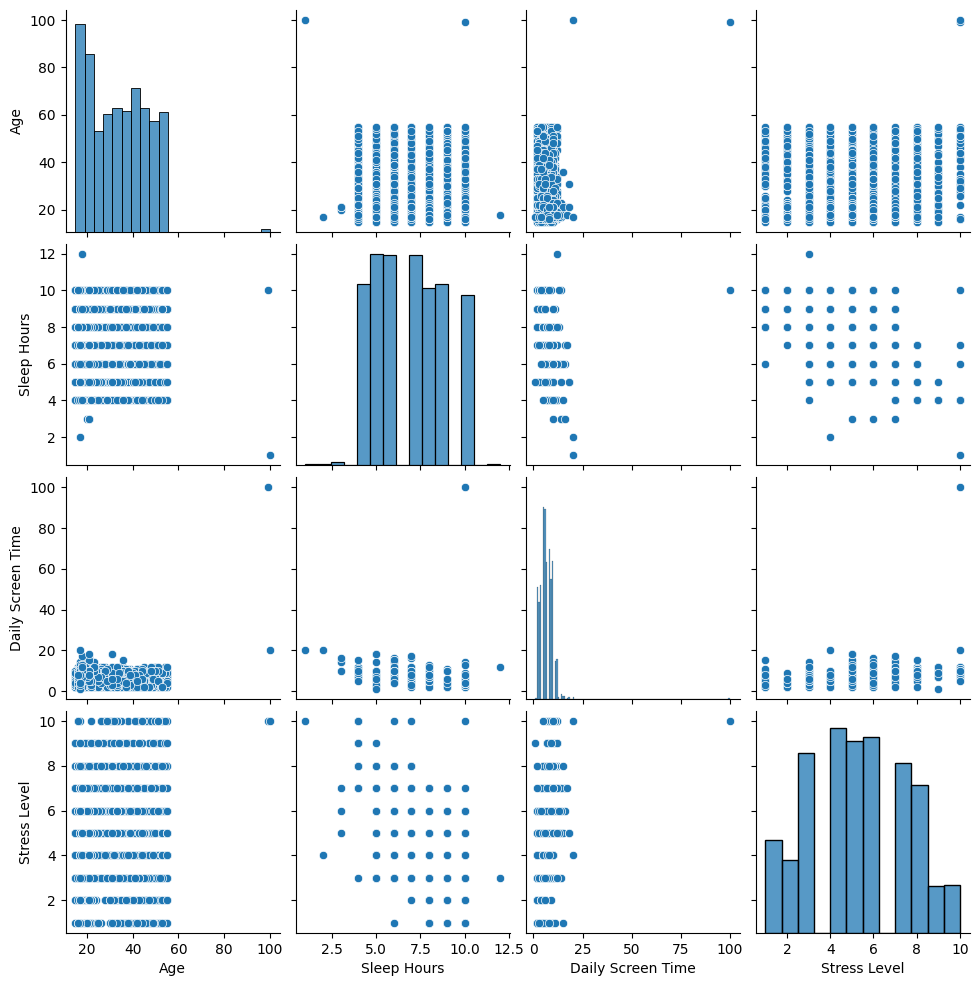

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(combined_data.select_dtypes(include='number').dropna())
plt.show()

In [28]:
numeric_cols = combined_data.select_dtypes(include=['int64']).columns
print(numeric_cols)

Index(['Age', 'Sleep Hours', 'Daily Screen Time', 'Stress Level'], dtype='object')


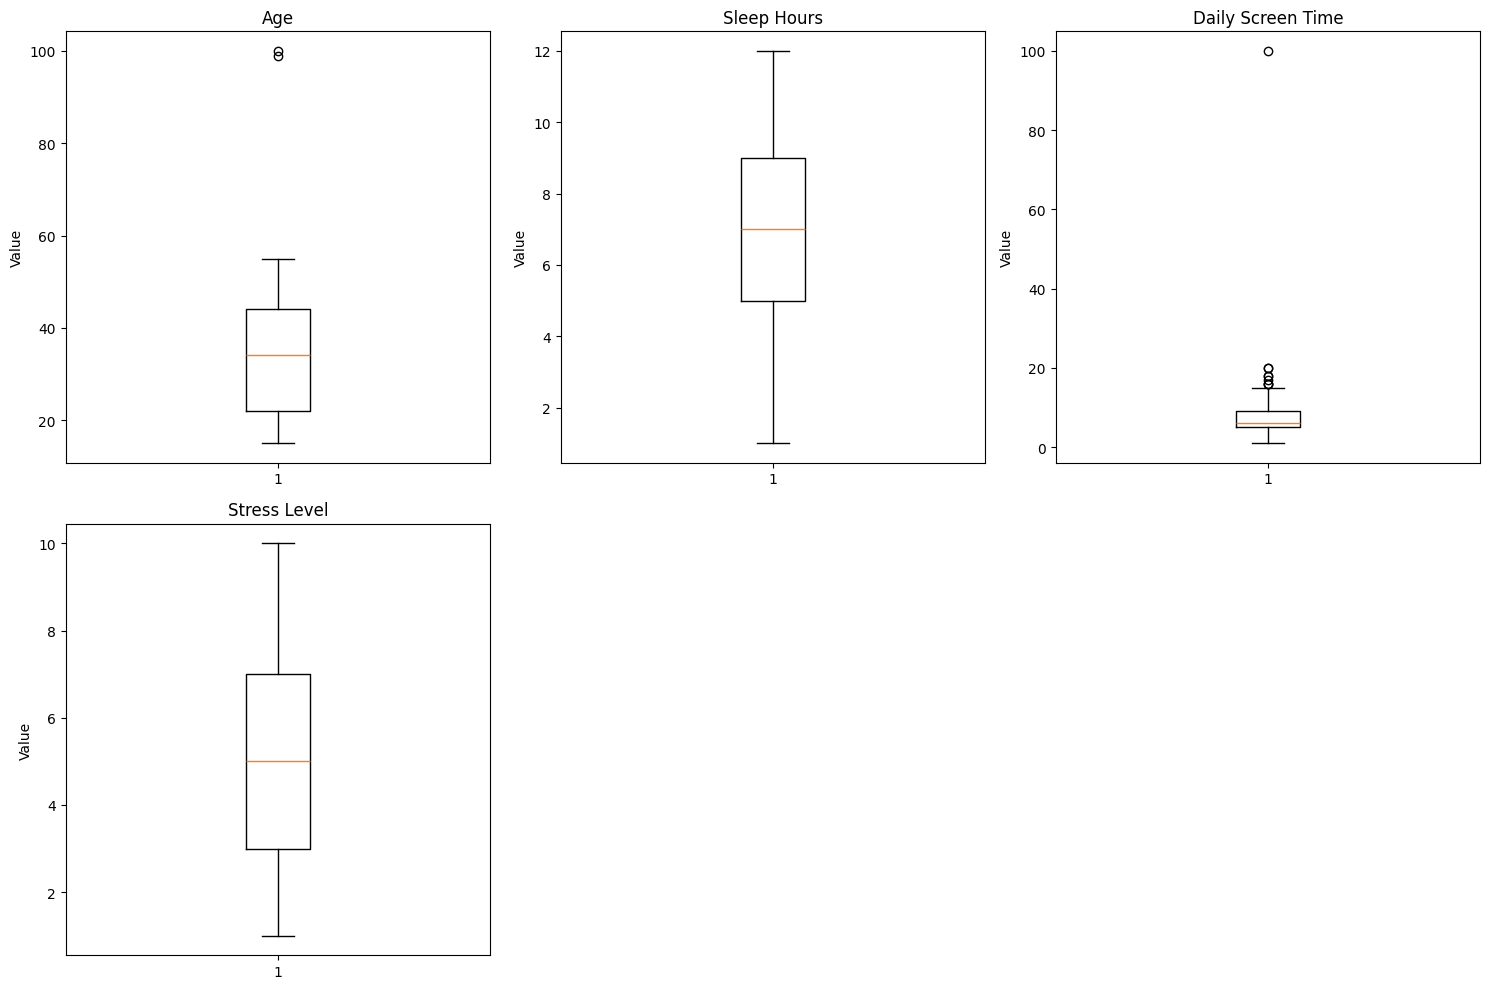

In [29]:
import numpy as np
import matplotlib.pyplot as plt

numeric_cols = combined_data.select_dtypes(include=['int64']).columns
n_cols = 3   # number of plots per row
n_rows = int(np.ceil(len(numeric_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))

axes = axes.flatten()

for i, col in enumerate(numeric_cols): #enumerate คือฟังก์ชันใน Python ที่ใช้ วนลูปพร้อมกับได้ “ลำดับ index” ไปด้วย
    axes[i].boxplot(combined_data[col])
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Value')


# Remove empty subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [30]:
from scipy.stats.mstats import winsorize

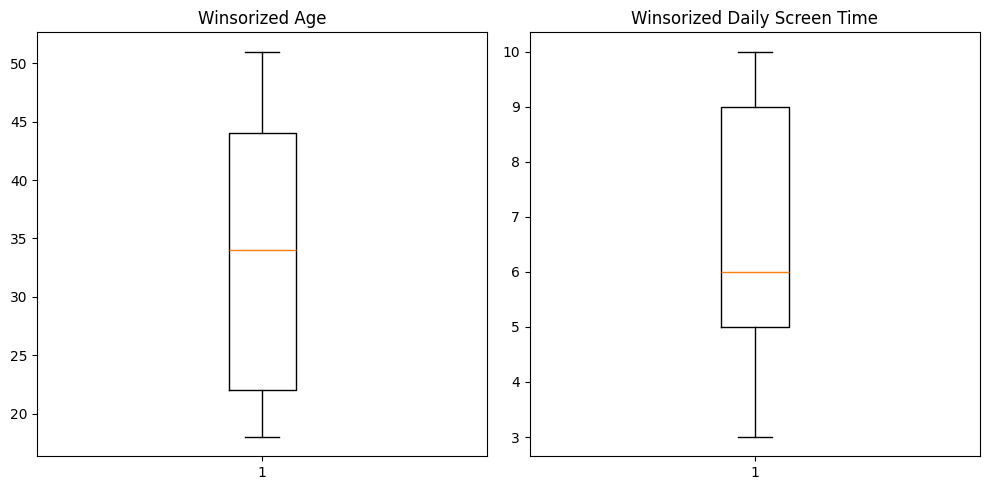

In [31]:
df_age = winsorize(combined_data['Age'], (0.1, 0.1))
df_daily_screen_time = winsorize(combined_data['Daily Screen Time'], (0.1, 0.1))

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes = axes.flatten()

axes[0].boxplot(df_age)
axes[0].set_title('Winsorized Age')

axes[1].boxplot(df_daily_screen_time)
axes[1].set_title('Winsorized Daily Screen Time')

plt.tight_layout()
plt.show()

###Label Encoding
(ถ้าใช้ .map() ของ pandas ไม่ต้อง import LabelEncoder จาก sklearn ต้อง import เฉพาะตอนที่จะใช้ object ของมัน from sklearn.preprocessing import LabelEncoder)

In [32]:

# กำหนดลำดับการ Mapping ด้วยตัวเอง (Manual Ordinal Mapping)
# Yes/No Mapping
binary_mapping = {'Yes': 1, 'No': 0}

# สร้าง DataFrame ใหม่สำหรับเก็บค่าที่ Map แล้ว
combined_data_df2 = pd.DataFrame()

# ทำการ Map ค่าตามลำดับที่กำหนด
combined_data_df2['Use Before Sleep_enc'] = combined_data['Use Before Sleep'].map(binary_mapping)
combined_data_df2['Anxiety/Low Mood_enc'] = combined_data['Anxiety/Low Mood'].map(binary_mapping)
combined_data_df2['Wellness Apps_enc'] = combined_data['Wellness Apps'].map(binary_mapping)

# แสดงผลลัพธ์
display(combined_data_df2)

,Use Before Sleep_enc,Anxiety/Low Mood_enc,Wellness Apps_enc
0,1,0,0
1,0,1,1
2,0,0,1
3,1,1,0
4,1,1,0
...,...,...,...
1176,1,0,1
1177,1,0,0
1178,1,0,1
1179,1,0,0


###OrdinalEncoder
แปลงแบบกำหนดลำดับเองโดยใช้ OrdinalEncoder โดยฟังก์ชันนี้จะคืนค่าเป็น float ดังนั้นถ้าอยากได้เป็นจำนวนเต็ม จะต้องใช้คำสั่ง .astype(int)

In [33]:
from sklearn.preprocessing import OrdinalEncoder

orders = [
    ["No", "Sometimes", "Yes"], #Feel Rested
    ["Bad", "Good"], #Sleep Quality
]

encoder = OrdinalEncoder(categories=orders)

# Encode multiple attributes at once
combined_data_df2[["Feel Rested_enc", "Sleep Quality_enc"]] = encoder.fit_transform(combined_data[["Feel Rested", "Sleep Quality"]]).astype(int)
combined_data_df2

,Use Before Sleep_enc,Anxiety/Low Mood_enc,Wellness Apps_enc,Feel Rested_enc,Sleep Quality_enc
0,1,0,0,2,0
1,0,1,1,0,0
2,0,0,1,1,0
3,1,1,0,2,1
4,1,1,0,2,1
...,...,...,...,...,...
1176,1,0,1,2,1
1177,1,0,0,0,1
1178,1,0,1,2,0
1179,1,0,0,0,0


###Onehot with OneHotEncoder Library

In [34]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False) #🔎 sparse_output=False ปกติ OneHotEncoder จะให้ผลลัพธ์เป็น Sparse Matrix แต่เราบอกให้เป็น array ปกติ (dense array) เพื่อเอาไปทำ DataFrame ได้ง่าย
encoded = encoder.fit_transform(combined_data[['Screen Time Affects Sleep?']])

df_onehot = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(['Screen Time Affects Sleep?'])).astype(int) #get_feature_names_out()ช่วยสร้างชื่อคอลัมน์อัตโนมัติ

df_onehot

,Screen Time Affects Sleep?_No,Screen Time Affects Sleep?_Not Sure,Screen Time Affects Sleep?_Yes
0,0,0,1
1,0,0,1
2,0,0,1
3,1,0,0
4,0,0,1
...,...,...,...
1176,0,1,0
1177,0,1,0
1178,0,0,1
1179,0,0,1


### 2.6 รวมคอลัมน์ที่ผ่านการ Encode เข้ากับข้อมูลหลัก
เราจะนำคอลัมน์ตัวเลขจาก `combined_data` มารวมกับ `combined_data_df2` (Encodr&Ordinal) และ `df_onehot` (One-hot)

In [35]:
# เลือกเฉพาะคอลัมน์ที่เป็นตัวเลขจากข้อมูลหลัก
numeric_data = combined_data.select_dtypes(include=['int64']).reset_index(drop=True)

# นำมา concat กันในแนวแกนคอลัมน์ (axis=1)
final_df = pd.concat([numeric_data, combined_data_df2, df_onehot], axis=1)

print('--- ข้อมูลสุดท้ายที่พร้อมสำหรับ Model (Final DataFrame) ---')
print(f'Shape ของข้อมูล: {final_df.shape}')
display(final_df.head())
final_df.info()

--- ข้อมูลสุดท้ายที่พร้อมสำหรับ Model (Final DataFrame) ---
Shape ของข้อมูล: (1181, 12)


,Age,Sleep Hours,Daily Screen Time,Stress Level,Use Before Sleep_enc,Anxiety/Low Mood_enc,Wellness Apps_enc,Feel Rested_enc,Sleep Quality_enc,Screen Time Affects Sleep?_No,Screen Time Affects Sleep?_Not Sure,Screen Time Affects Sleep?_Yes
0,47,4,11,10,1,0,0,2,0,0,0,1
1,48,4,8,7,0,1,1,0,0,0,0,1
2,40,7,10,4,0,0,1,1,0,0,0,1
3,26,10,5,1,1,1,0,2,1,1,0,0
4,47,5,7,7,1,1,0,2,1,0,0,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1181 entries, 0 to 1180
Data columns (total 12 columns):
 #   Column                               Non-Null Count  Dtype
---  ------                               --------------  -----
 0   Age                                  1181 non-null   int64
 1   Sleep Hours                          1181 non-null   int64
 2   Daily Screen Time                    1181 non-null   int64
 3   Stress Level                         1181 non-null   int64
 4   Use Before Sleep_enc                 1181 non-null   int64
 5   Anxiety/Low Mood_enc                 1181 non-null   int64
 6   Wellness Apps_enc                    1181 non-null   int64
 7   Feel Rested_enc                      1181 non-null   int64
 8   Sleep Quality_enc                    1181 non-null   int64
 9   Screen Time Affects Sleep?_No        1181 non-null   int64
 10  Screen Time Affects Sleep?_Not Sure  1181 non-null   int64
 11  Screen Time Affects Sleep?_Yes       1181 non-null   int

### 2.8 Update Winsorized Data into Final DataFrame
Update the 'Age' and 'Daily Screen Time' in `final_df` with the winsorized values to reduce the impact of outliers on the model.

In [36]:
from scipy.stats.mstats import winsorize

# Apply winsorization to the actual columns in final_df
final_df['Age'] = winsorize(final_df['Age'], (0.1, 0.1))
final_df['Daily Screen Time'] = winsorize(final_df['Daily Screen Time'], (0.1, 0.1))

print("Updated final_df with winsorized values.")
display(final_df.head())

Updated final_df with winsorized values.


,Age,Sleep Hours,Daily Screen Time,Stress Level,Use Before Sleep_enc,Anxiety/Low Mood_enc,Wellness Apps_enc,Feel Rested_enc,Sleep Quality_enc,Screen Time Affects Sleep?_No,Screen Time Affects Sleep?_Not Sure,Screen Time Affects Sleep?_Yes
0,47,4,10,10,1,0,0,2,0,0,0,1
1,48,4,8,7,0,1,1,0,0,0,0,1
2,40,7,10,4,0,0,1,1,0,0,0,1
3,26,10,5,1,1,1,0,2,1,1,0,0
4,47,5,7,7,1,1,0,2,1,0,0,1


## 3. Exploratory Data Analysis (EDA)
วิเคราะห์ความสัมพันธ์ของตัวแปรและลักษณะการกระจายตัวของข้อมูล

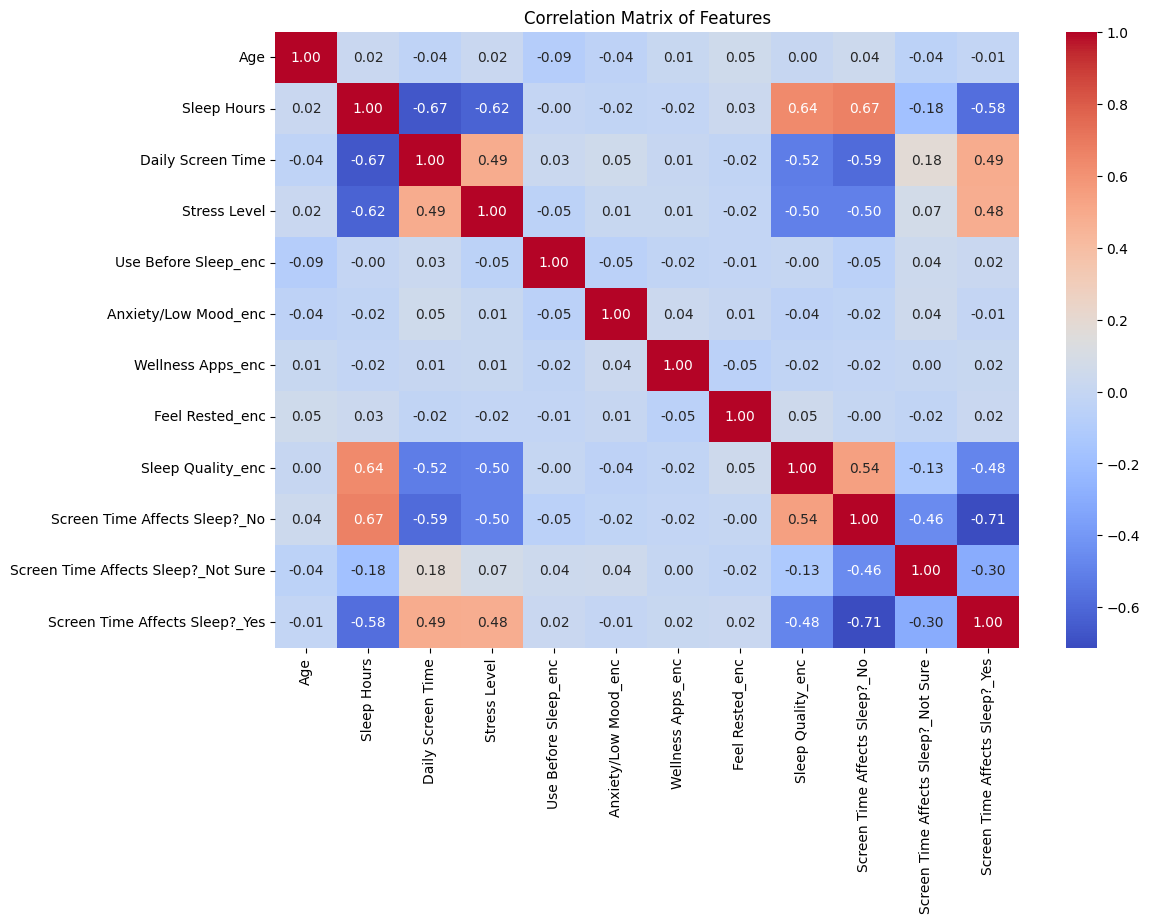

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

# 3.1 Heatmap แสดงความสัมพันธ์ (Correlation)
plt.figure(figsize=(12, 8))
correlation_matrix = final_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Features')
plt.show()

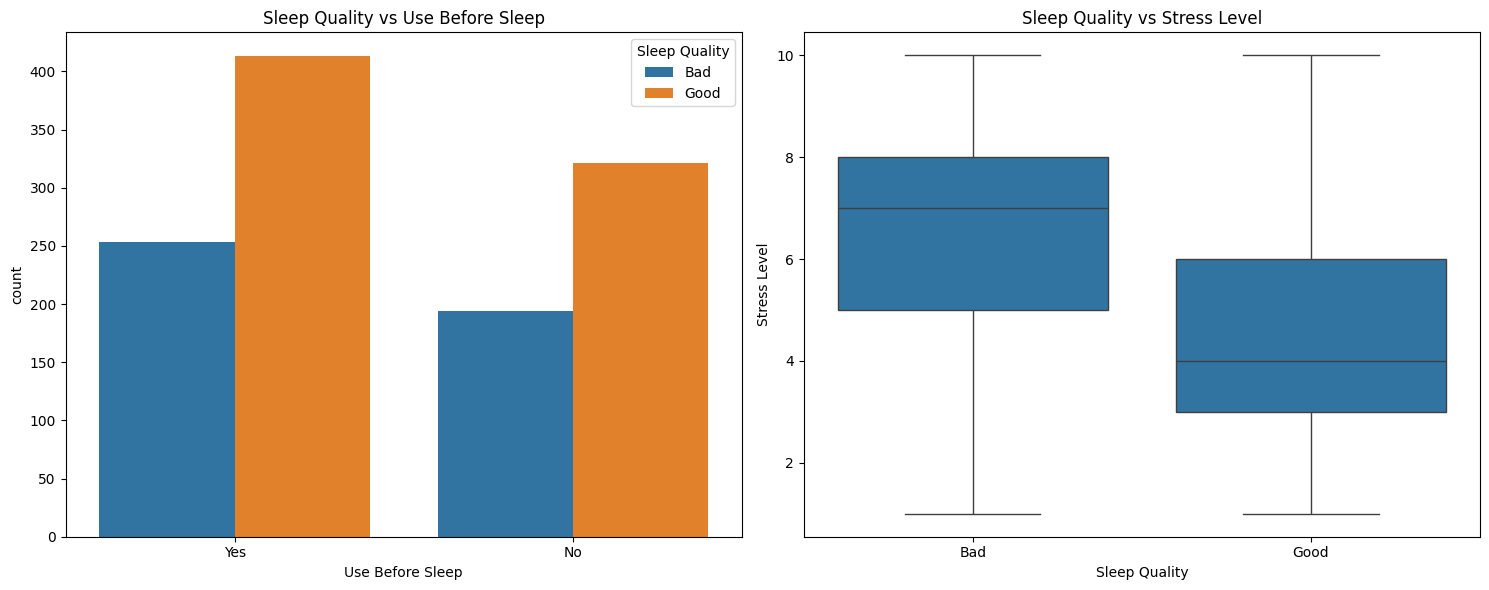

In [38]:
# 3.2 เปรียบเทียบ Sleep Quality กับปัจจัยต่างๆ
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# การใช้มือถือก่อนนอนกับคุณภาพการนอน
sns.countplot(data=combined_data, x='Use Before Sleep', hue='Sleep Quality', ax=axes[0])
axes[0].set_title('Sleep Quality vs Use Before Sleep')

# ความเครียดกับคุณภาพการนอน
sns.boxplot(data=combined_data, x='Sleep Quality', y='Stress Level', ax=axes[1])
axes[1].set_title('Sleep Quality vs Stress Level')

plt.tight_layout()
plt.show()

### 4. เตรียมข้อมูลโดยใช้ Screen Time Affects Sleep? เป็น Target
ทำการ Encode เป้าหมาย และ Scaling ข้อมูลใหม่

In [39]:
from sklearn.preprocessing import LabelEncoder

# 1. เตรียม Target (y) และ Encode เป็นตัวเลข
le = LabelEncoder()
y_encoded = le.fit_transform(combined_data['Screen Time Affects Sleep?'])

# 2. เตรียม DataFrame หลักที่รวม Features และ Target ที่ Encode แล้ว (ยังไม่ Scaling)
cols_to_drop = ['Screen Time Affects Sleep?_No', 'Screen Time Affects Sleep?_Not Sure', 'Screen Time Affects Sleep?_Yes']
final_data_for_csv = final_df.drop(columns=cols_to_drop).copy()
final_data_for_csv['Screen Time Affects Sleep'] = y_encoded

# แสดง Class Mapping
mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(f'Target classes mapping: {mapping}')
display(final_data_for_csv.head(10))

Target classes mapping: {'No': np.int64(0), 'Not Sure': np.int64(1), 'Yes': np.int64(2)}


,Age,Sleep Hours,Daily Screen Time,Stress Level,Use Before Sleep_enc,Anxiety/Low Mood_enc,Wellness Apps_enc,Feel Rested_enc,Sleep Quality_enc,Screen Time Affects Sleep
0,47,4,10,10,1,0,0,2,0,2
1,48,4,8,7,0,1,1,0,0,2
2,40,7,10,4,0,0,1,1,0,2
3,26,10,5,1,1,1,0,2,1,0
4,47,5,7,7,1,1,0,2,1,2
5,51,6,8,7,1,0,0,0,1,1
6,20,9,3,1,0,0,0,1,1,0
7,21,5,9,7,0,0,0,2,0,0
8,40,8,5,4,1,1,0,0,1,0
9,18,6,9,6,1,1,0,1,1,1


In [40]:
#บันทึกไฟล์ที่ Encode แล้วแต่ยังไม่ Scaling ลง Google Drive
save_path_encoded = '/content/drive/MyDrive/datasetProjectSleep/encoded_sleep_data_ready.csv'
final_data_for_csv.to_csv(save_path_encoded, index=False)
print(f'บันทึกไฟล์ (Encoded only) เรียบร้อยแล้วที่: {save_path_encoded}')

บันทึกไฟล์ (Encoded only) เรียบร้อยแล้วที่: /content/drive/MyDrive/datasetProjectSleep/encoded_sleep_data_ready.csv


In [41]:
path = '/content/drive/MyDrive/datasetProjectSleep/encoded_sleep_data_ready.csv'
sleepdata = pd.read_csv(path) ## Dataset is now stored in a Pandas Dataframe
print ("Dataset Lenght:: ", len(sleepdata)) #แสดงจำนวนแถว (จำนวนข้อมูลทั้งหมด)
print ("Dataset Shape:: ", sleepdata.shape) #แสดงขนาดข้อมูลในรูปแบบ (จำนวนแถว, จำนวนคอลัมน์)
sleepdata

Dataset Lenght::  1181
Dataset Shape::  (1181, 10)


,Age,Sleep Hours,Daily Screen Time,Stress Level,Use Before Sleep_enc,Anxiety/Low Mood_enc,Wellness Apps_enc,Feel Rested_enc,Sleep Quality_enc,Screen Time Affects Sleep
0,47,4,10,10,1,0,0,2,0,2
1,48,4,8,7,0,1,1,0,0,2
2,40,7,10,4,0,0,1,1,0,2
3,26,10,5,1,1,1,0,2,1,0
4,47,5,7,7,1,1,0,2,1,2
...,...,...,...,...,...,...,...,...,...,...
1176,21,10,8,4,1,0,1,2,1,1
1177,18,7,8,8,1,0,0,0,1,1
1178,18,7,3,6,1,0,1,2,0,2
1179,18,6,4,6,1,0,0,0,0,2


In [42]:
# ใช้ข้อมูลจาก final_data_for_csv ที่เตรียมไว้แล้ว ซึ่งสะอาดและไม่มี Header ปน
X = final_data_for_csv.drop('Screen Time Affects Sleep', axis=1)
y = final_data_for_csv['Screen Time Affects Sleep']

print("Shape ของ X:", X.shape)
X.head()

Shape ของ X: (1181, 9)


,Age,Sleep Hours,Daily Screen Time,Stress Level,Use Before Sleep_enc,Anxiety/Low Mood_enc,Wellness Apps_enc,Feel Rested_enc,Sleep Quality_enc
0,47,4,10,10,1,0,0,2,0
1,48,4,8,7,0,1,1,0,0
2,40,7,10,4,0,0,1,1,0
3,26,10,5,1,1,1,0,2,1
4,47,5,7,7,1,1,0,2,1


In [43]:
y.value_counts()

,count
Screen Time Affects Sleep,
0,615
2,376
1,190


### 5. การจัดการ Scaling แยกตามประเภทข้อมูล
เราจะทำ Scaling เฉพาะตัวแปรที่เป็นตัวเลขต่อเนื่อง (Numeric) และคงตัวแปรที่เป็นหมวดหมู่ (Encoded) ไว้ตามเดิม

In [44]:
from sklearn.preprocessing import StandardScaler

# 1. เลือกคอลัมน์ที่เป็นตัวเลขต่อเนื่อง
continuous_features = ['Age', 'Sleep Hours', 'Daily Screen Time', 'Stress Level']
# 2. เลือกคอลัมน์ที่เป็น Encoded อยู่แล้ว
encoded_features = ['Use Before Sleep_enc', 'Anxiety/Low Mood_enc', 'Wellness Apps_enc', 'Feel Rested_enc', 'Sleep Quality_enc']

# สร้าง DataFrame ใหม่สำหรับเก็บค่าที่ Scale แล้ว
X_final = final_data_for_csv.copy()

# ทำ Scaling เฉพาะกลุ่ม continuous
scaler = StandardScaler()
X_final[continuous_features] = scaler.fit_transform(X_final[continuous_features])

print('--- ข้อมูลที่เตรียมเสร็จสมบูรณ์ (Scaled เฉพาะ Numeric, คงค่า Encoded) ---')
display(X_final.head())
# ตรวจสอบว่าคอลัมน์ _enc ยังคงเป็นค่า 0, 1, 2 เหมือนเดิมหรือไม่
print('\nค่าในคอลัมน์ Encoded ยังคงเป็นเลขจำนวนเต็ม:')
display(X_final[encoded_features].head())

--- ข้อมูลที่เตรียมเสร็จสมบูรณ์ (Scaled เฉพาะ Numeric, คงค่า Encoded) ---


,Age,Sleep Hours,Daily Screen Time,Stress Level,Use Before Sleep_enc,Anxiety/Low Mood_enc,Wellness Apps_enc,Feel Rested_enc,Sleep Quality_enc,Screen Time Affects Sleep
0,1.138024,-1.463638,1.451883,2.088519,1,0,0,2,0,2
1,1.224361,-1.463638,0.619315,0.786685,0,1,1,0,0,2
2,0.533666,0.055304,1.451883,-0.515148,0,0,1,1,0,2
3,-0.675051,1.574247,-0.629537,-1.816982,1,1,0,2,1,0
4,1.138024,-0.957324,0.203031,0.786685,1,1,0,2,1,2



ค่าในคอลัมน์ Encoded ยังคงเป็นเลขจำนวนเต็ม:


,Use Before Sleep_enc,Anxiety/Low Mood_enc,Wellness Apps_enc,Feel Rested_enc,Sleep Quality_enc
0,1,0,0,2,0
1,0,1,1,0,0
2,0,0,1,1,0
3,1,1,0,2,1
4,1,1,0,2,1


In [45]:
sleepdata = sleepdata[sleepdata['Screen Time Affects Sleep'].isin([0, 1, 2])]

In [46]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, FunctionTransformer
import pandas as pd
import numpy as np
from scipy.stats.mstats import winsorize

# 1. ฟังก์ชันสำหรับการ Clean (Winsorization)
def winsorize_data(X):
    X_copy = X.copy()
    if isinstance(X_copy, pd.DataFrame):
        for col in X_copy.columns:
            # ตรวจสอบว่ามีข้อมูลก่อนทำ winsorize
            if len(X_copy[col]) > 0:
                X_copy[col] = winsorize(X_copy[col], (0.1, 0.1))
    return X_copy

# 2. กำหนดกลุ่ม Features
numeric_features = ['Age', 'Sleep Hours', 'Daily Screen Time', 'Stress Level']
encoded_features = ['Use Before Sleep_enc', 'Anxiety/Low Mood_enc', 'Wellness Apps_enc', 'Feel Rested_enc', 'Sleep Quality_enc']

# 3. สร้าง Transformer สำหรับข้อมูลตัวเลข (Clean -> Scale)
numeric_transformer = Pipeline(steps=[
    ('winsorizer', FunctionTransformer(winsorize_data)),
    ('scaler', StandardScaler())
])

# 4. รวมการจัดการข้อมูลด้วย ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('passthrough', 'passthrough', encoded_features)
    ]
)

# 5. สร้าง Pipeline หลัก
data_pipeline = Pipeline(steps=[('preprocessor', preprocessor)])

# ทดสอบการใช้งาน Pipeline ด้วย X ที่เตรียมใหม่
X_transformed = data_pipeline.fit_transform(X)

# แสดงผลลัพธ์
feature_names = numeric_features + encoded_features
X_transformed_df = pd.DataFrame(X_transformed, columns=feature_names)
print('--- ข้อมูลที่ผ่าน Pipeline (Cleaned & Transformed) ---')
display(X_transformed_df.head())

--- ข้อมูลที่ผ่าน Pipeline (Cleaned & Transformed) ---


,Age,Sleep Hours,Daily Screen Time,Stress Level,Use Before Sleep_enc,Anxiety/Low Mood_enc,Wellness Apps_enc,Feel Rested_enc,Sleep Quality_enc
0,1.138024,-1.478900,1.451883,1.419594,1.0,0.0,0.0,2.0,0.0
1,1.224361,-1.478900,0.619315,0.921513,0.0,1.0,1.0,0.0,0.0
2,0.533666,0.053189,1.451883,-0.572730,0.0,0.0,1.0,1.0,0.0
3,-0.675051,1.585277,-0.629537,-1.568892,1.0,1.0,0.0,2.0,1.0
4,1.138024,-0.968204,0.203031,0.921513,1.0,1.0,0.0,2.0,1.0


###บันทึก Pipeline เก็บไว้ใน Google Drive

In [47]:
import joblib

# กำหนดพาธสำหรับบันทึก Pipeline
pipeline_save_path = '/content/drive/MyDrive/datasetProjectSleep/sleep_data_pipeline.joblib'

# บันทึก Pipeline object
joblib.dump(data_pipeline, pipeline_save_path)
print(f"บันทึก Pipeline สำเร็จที่: {pipeline_save_path}")

บันทึก Pipeline สำเร็จที่: /content/drive/MyDrive/datasetProjectSleep/sleep_data_pipeline.joblib


### 6. Model Training and Experiment Tracking
We will use MLflow to track different model architectures and their performance metrics.

In [48]:
!pip install mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 72.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 70.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 60.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 892.1/892.1 kB 41.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2

In [49]:
import mlflow
import mlflow.sklearn
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_transformed_df, y, test_size=0.2, random_state=42)

def train_and_log_model(model, model_name):
    with mlflow.start_run(run_name=model_name):
        model.fit(X_train, y_train)
        predictions = model.predict(X_test)
        accuracy = accuracy_score(y_test, predictions)

        # Log parameters and metrics
        mlflow.log_param("model_type", model_name)
        mlflow.log_metric("accuracy", accuracy)

        # Log the model
        mlflow.sklearn.log_model(model, model_name)

        print(f"{model_name} Accuracy: {accuracy:.4f}")
        print(classification_report(y_test, predictions))

# Initialize MLflow experiment
mlflow.set_experiment("Sleep_Quality_Prediction")

# 1. Random Forest
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
train_and_log_model(rf_model, "RandomForest")

# 2. Support Vector Machine
svm_model = SVC(kernel='rbf', C=1.0, probability=True)
train_and_log_model(svm_model, "SVM")

# 3. Neural Network (MLP)
mlp_model = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
train_and_log_model(mlp_model, "NeuralNetwork_MLP")

2026/05/22 09:29:42 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/22 09:29:42 INFO mlflow.store.db.utils: Updating database tables
2026/05/22 09:29:47 INFO mlflow.tracking.fluent: Experiment with name 'Sleep_Quality_Prediction' does not exist. Creating a new experiment.
2026/05/22 09:29:48 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/22 09:29:48 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


RandomForest Accuracy: 0.7089
              precision    recall  f1-score   support

           0       0.82      0.83      0.82       128
           1       0.36      0.29      0.32        34
           2       0.66      0.69      0.68        75

    accuracy                           0.71       237
   macro avg       0.61      0.61      0.61       237
weighted avg       0.70      0.71      0.70       237



2026/05/22 09:29:57 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/22 09:29:58 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


SVM Accuracy: 0.7173
              precision    recall  f1-score   support

           0       0.84      0.83      0.83       128
           1       0.29      0.15      0.20        34
           2       0.63      0.79      0.70        75

    accuracy                           0.72       237
   macro avg       0.59      0.59      0.58       237
weighted avg       0.70      0.72      0.70       237



/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
2026/05/22 09:30:04 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/22 09:30:04 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


NeuralNetwork_MLP Accuracy: 0.7257
              precision    recall  f1-score   support

           0       0.84      0.84      0.84       128
           1       0.37      0.38      0.38        34
           2       0.70      0.69      0.70        75

    accuracy                           0.73       237
   macro avg       0.64      0.64      0.64       237
weighted avg       0.73      0.73      0.73       237



### 6.2 Handling Class Imbalance with SMOTE
เราจะใช้ SMOTE เพื่อเพิ่มจำนวนตัวอย่างใน Class ที่มีน้อยให้สมดุลก่อนทำการเทรนใหม่

In [50]:
!pip install imbalanced-learn

In [51]:
from imblearn.over_sampling import SMOTE
from collections import Counter

# ตรวจสอบจำนวนข้อมูลก่อนทำ SMOTE
print(f"Original training dataset shape: {Counter(y_train)}")

# ทำ SMOTE เฉพาะ Training Data
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Resampled training dataset shape: {Counter(y_train_res)}")

Original training dataset shape: Counter({0: 487, 2: 301, 1: 156})
Resampled training dataset shape: Counter({2: 487, 1: 487, 0: 487})


### 6.3 Re-training Models with Balanced Data
เราจะลองเทรน SVM และ MLP อีกครั้งด้วยข้อมูลที่ผ่านการ Re-sample แล้ว

In [52]:
# สร้าง function ใหม่เพื่อใช้กับข้อมูลที่ resample แล้ว
def train_and_log_resampled_model(model, model_name):
    with mlflow.start_run(run_name=f"{model_name}_SMOTE"):
        model.fit(X_train_res, y_train_res)
        predictions = model.predict(X_test)
        accuracy = accuracy_score(y_test, predictions)

        mlflow.log_param("model_type", model_name)
        mlflow.log_param("resampling", "SMOTE")
        mlflow.log_metric("accuracy", accuracy)

        print(f"{model_name} with SMOTE Accuracy: {accuracy:.4f}")
        print(classification_report(y_test, predictions))

# 1. SVM with SMOTE
svm_smote = SVC(kernel='rbf', C=1.0, probability=True)
train_and_log_resampled_model(svm_smote, "SVM")

# 2. MLP with SMOTE (Optimized parameters)
mlp_smote = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=2000, random_state=42)
train_and_log_resampled_model(mlp_smote, "NeuralNetwork_MLP")

SVM with SMOTE Accuracy: 0.7384
              precision    recall  f1-score   support

           0       0.99      0.77      0.86       128
           1       0.34      0.65      0.45        34
           2       0.74      0.73      0.74        75

    accuracy                           0.74       237
   macro avg       0.69      0.72      0.68       237
weighted avg       0.82      0.74      0.76       237

NeuralNetwork_MLP with SMOTE Accuracy: 0.7004
              precision    recall  f1-score   support

           0       0.79      0.80      0.80       128
           1       0.40      0.35      0.38        34
           2       0.67      0.68      0.68        75

    accuracy                           0.70       237
   macro avg       0.62      0.61      0.62       237
weighted avg       0.69      0.70      0.70       237



### 6.4 Hyperparameter Tuning for SVM using GridSearchCV
เราจะทำการค้นหาชุดค่า Parameter ที่ดีที่สุดเพื่อให้ SVM มีประสิทธิภาพสูงสุดบนข้อมูลที่สมดุลแล้ว

In [53]:
from sklearn.model_selection import GridSearchCV

# กำหนด Parameter Grid
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.1, 0.01],
    'kernel': ['rbf', 'poly', 'sigmoid']
}

# ตั้งค่า GridSearchCV
grid_search = GridSearchCV(
    SVC(probability=True, random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1
)

# เริ่มการค้นหาบนข้อมูลที่ทำ SMOTE แล้ว
print("Searching for best hyperparameters...")
grid_search.fit(X_train_res, y_train_res)

# แสดงค่าที่ดีที่สุด
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Score: {grid_search.best_score_:.4f}")

# นำโมเดลที่ดีที่สุดมาประเมินผลและบันทึกใน MLflow
train_and_log_resampled_model(grid_search.best_estimator_, "SVM_Optimized_GridSearch")

Searching for best hyperparameters...
Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best Parameters: {'C': 100, 'gamma': 'scale', 'kernel': 'rbf'}
Best Cross-Validation Score: 0.8454
SVM_Optimized_GridSearch with SMOTE Accuracy: 0.7257
              precision    recall  f1-score   support

           0       0.79      0.87      0.83       128
           1       0.47      0.47      0.47        34
           2       0.71      0.60      0.65        75

    accuracy                           0.73       237
   macro avg       0.66      0.65      0.65       237
weighted avg       0.72      0.73      0.72       237



### 6.5 Save the Optimized SVM Model
บันทึกโมเดลที่ดีที่สุดจากการทำ GridSearchCV เพื่อนำไปใช้งานจริง

In [55]:
import joblib

# กำหนดพาธสำหรับบันทึกโมเดล
model_save_path = '/content/drive/MyDrive/datasetProjectSleep/optimized_svm_model.joblib'

# ดึงตัวโมเดลที่ดีที่สุดจาก grid_search
best_svm_model = grid_search.best_estimator_

# บันทึกโมเดล
joblib.dump(best_svm_model, model_save_path)

print(f"บันทึกโมเดล SVM ที่ปรับจูนแล้วสำเร็จที่: {model_save_path}")

บันทึกโมเดล SVM ที่ปรับจูนแล้วสำเร็จที่: /content/drive/MyDrive/datasetProjectSleep/optimized_svm_model.joblib


### 7. Meta-Learner Implementation (Stacking)
เราจะสร้าง Meta-Features จาก Out-of-fold predictions ของ base models แล้วใช้ MLP ในการสรุปผลขั้นสุดท้าย

In [56]:
from sklearn.ensemble import StackingClassifier
from sklearn.neural_network import MLPClassifier

# 1. กำหนด Base Models (ใช้ตัวที่เราเทรนและปรับจูนแล้ว)
base_models = [
    ('rf', rf_model),
    ('svm', best_svm_model),
    ('mlp', mlp_smote)
]

# 2. กำหนด Meta-Learner (MLP)
meta_learner = MLPClassifier(
    hidden_layer_sizes=(32, 16),
    max_iter=1000,
    random_state=42,
    early_stopping=True
)

# 3. สร้าง Stacking Classifier
stacking_model = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_learner,
    cv=5,
    stack_method='predict_proba',
    n_jobs=-1
)

# 4. เทรน Meta-Learner ด้วยข้อมูลที่สมดุลแล้ว
print("Training Stacking Meta-Learner...")
with mlflow.start_run(run_name="Stacking_MLP_MetaLearner"):
    stacking_model.fit(X_train_res, y_train_res)

    # ประเมินผล
    y_pred = stacking_model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)

    mlflow.log_metric("accuracy", accuracy)
    mlflow.sklearn.log_model(stacking_model, "stacking_meta_learner")

    print(f"Stacking Meta-Learner Accuracy: {accuracy:.4f}")
    print(classification_report(y_test, y_pred))

Training Stacking Meta-Learner...


2026/05/22 09:37:30 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/22 09:37:31 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Stacking Meta-Learner Accuracy: 0.7089
              precision    recall  f1-score   support

           0       0.79      0.81      0.80       128
           1       0.45      0.38      0.41        34
           2       0.67      0.68      0.68        75

    accuracy                           0.71       237
   macro avg       0.64      0.62      0.63       237
weighted avg       0.70      0.71      0.71       237



### 7.1 Hyperparameter Tuning สำหรับ Meta-Learner (MLP)
เราจะใช้ GridSearchCV เพื่อค้นหา `hidden_layer_sizes`, `activation`, และ `alpha` (regularization) ที่ดีที่สุดสำหรับ Meta-model

In [57]:
from sklearn.model_selection import GridSearchCV

# 1. กำหนดช่วงของ Parameter ที่ต้องการทดสอบ
meta_param_grid = {
    'final_estimator__hidden_layer_sizes': [(16,), (32, 16), (64, 32)],
    'final_estimator__activation': ['tanh', 'relu'],
    'final_estimator__alpha': [0.0001, 0.001, 0.01],
    'final_estimator__learning_rate_init': [0.001, 0.01]
}

# 2. ตั้งค่า GridSearchCV โดยใช้ stacking_model เดิมเป็นต้นแบบ
grid_stacking = GridSearchCV(
    estimator=stacking_model,
    param_grid=meta_param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# 3. เริ่มการค้นหา
print("Searching for best Meta-Learner parameters...")
grid_stacking.fit(X_train_res, y_train_res)

# 4. แสดงผลลัพธ์ที่ดีที่สุด
print(f"Best Meta-Params: {grid_stacking.best_params_}")

# 5. ประเมินผลและ Log ลง MLflow
with mlflow.start_run(run_name="Stacking_MLP_Optimized"):
    best_stacking = grid_stacking.best_estimator_
    y_pred_best = best_stacking.predict(X_test)
    best_acc = accuracy_score(y_test, y_pred_best)

    mlflow.log_params(grid_stacking.best_params_)
    mlflow.log_metric("accuracy", best_acc)

    print(f"Optimized Stacking Accuracy: {best_acc:.4f}")
    print(classification_report(y_test, y_pred_best))

Searching for best Meta-Learner parameters...
Fitting 3 folds for each of 36 candidates, totalling 108 fits
Best Meta-Params: {'final_estimator__activation': 'relu', 'final_estimator__alpha': 0.0001, 'final_estimator__hidden_layer_sizes': (16,), 'final_estimator__learning_rate_init': 0.001}
Optimized Stacking Accuracy: 0.7342
              precision    recall  f1-score   support

           0       0.92      0.78      0.84       128
           1       0.40      0.41      0.41        34
           2       0.65      0.80      0.71        75

    accuracy                           0.73       237
   macro avg       0.65      0.66      0.65       237
weighted avg       0.76      0.73      0.74       237



### 7.2 Save the Optimized Stacking Model
บันทึกโมเดล Stacking ที่เป็นตัวที่ดีที่สุดจากการทำ GridSearchCV ลง Google Drive

In [58]:
import joblib

# กำหนดพาธสำหรับบันทึก Stacking Model
stacking_model_save_path = '/content/drive/MyDrive/datasetProjectSleep/optimized_stacking_model.joblib'

# บันทึกโมเดล (ใช้ตัวแปร best_stacking จาก cell ก่อนหน้า)
joblib.dump(best_stacking, stacking_model_save_path)

print(f"บันทึกโมเดล Stacking ที่ปรับจูนแล้วสำเร็จที่: {stacking_model_save_path}")

บันทึกโมเดล Stacking ที่ปรับจูนแล้วสำเร็จที่: /content/drive/MyDrive/datasetProjectSleep/optimized_stacking_model.joblib


### 8. Final Model Training: Random Forest
In this section, we train a Random Forest model using the resampled (balanced) data and evaluate it against our test set.

Random Forest Accuracy: 0.7004

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.78      0.79       128
           1       0.43      0.47      0.45        34
           2       0.66      0.67      0.66        75

    accuracy                           0.70       237
   macro avg       0.63      0.64      0.64       237
weighted avg       0.71      0.70      0.70       237



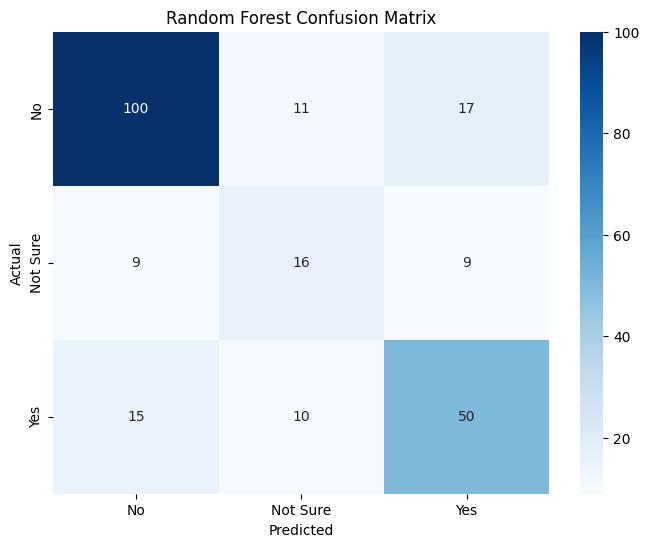

In [59]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Initialize the Random Forest Classifier
# Using resampled data (X_train_res, y_train_res) to handle class imbalance
rf_final = RandomForestClassifier(n_estimators=100, max_depth=None, random_state=42)

# Fit the model
rf_final.fit(X_train_res, y_train_res)

# Make predictions
y_pred_rf = rf_final.predict(X_test)

# Evaluation metrics
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f'Random Forest Accuracy: {accuracy_rf:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_rf))

# Plotting Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Random Forest Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

### 9. Training with Recursive Residual Corrector (RRC)
Recursive Residual Correction is a technique where the model iteratively predicts residuals to improve the final prediction. We will implement this using a simple Neural Network architecture in PyTorch.

In [60]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Prepare data for PyTorch
X_train_t = torch.tensor(X_train_res.values, dtype=torch.float32)
y_train_t = torch.tensor(y_train_res.values, dtype=torch.long)
X_test_t = torch.tensor(X_test.values, dtype=torch.float32)
y_test_t = torch.tensor(y_test.values, dtype=torch.long)

# Define RRC Module
class RRCModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_iterations=3):
        super(RRCModel, self).__init__()
        self.num_iterations = num_iterations
        self.base_fc = nn.Linear(input_dim, hidden_dim)
        self.residual_fc = nn.Linear(hidden_dim + output_dim, hidden_dim)
        self.output_fc = nn.Linear(hidden_dim, output_dim)
        self.relu = nn.ReLU()

    def forward(self, x):
        # Initial prediction
        h = self.relu(self.base_fc(x))
        out = self.output_fc(h)

        # Recursive refinement
        for _ in range(self.num_iterations - 1):
            combined = torch.cat([h, out], dim=1)
            h = self.relu(self.residual_fc(combined))
            out = out + self.output_fc(h) # Residual update

        return out

# Hyperparameters
input_dim = X_train_t.shape[1]
hidden_dim = 64
output_dim = 3 # 3 classes: No, Not Sure, Yes
num_epochs = 100
learning_rate = 0.001

# Model, Loss, Optimizer
model_rrc = RRCModel(input_dim, hidden_dim, output_dim)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_rrc.parameters(), lr=learning_rate)

# Training loop
model_rrc.train()
for epoch in range(num_epochs):
    optimizer.zero_grad()
    outputs = model_rrc(X_train_t)
    loss = criterion(outputs, y_train_t)
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 20 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

# Evaluation
model_rrc.eval()
with torch.no_grad():
    test_outputs = model_rrc(X_test_t)
    _, predicted = torch.max(test_outputs, 1)
    accuracy = (predicted == y_test_t).sum().item() / y_test_t.size(0)

print(f'\nRRC Model Accuracy: {accuracy:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, predicted.numpy()))

Epoch [20/100], Loss: 0.8121
Epoch [40/100], Loss: 0.7051
Epoch [60/100], Loss: 0.6588
Epoch [80/100], Loss: 0.6213
Epoch [100/100], Loss: 0.5877

RRC Model Accuracy: 0.7342

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.79      0.86       128
           1       0.34      0.59      0.43        34
           2       0.74      0.71      0.72        75

    accuracy                           0.73       237
   macro avg       0.67      0.69      0.67       237
weighted avg       0.79      0.73      0.75       237



### 9.1 ปรับปรุง RRC ด้วย Early Stopping และ Learning Rate Scheduler
เพื่อป้องกัน Overfitting และหาจุดที่ Model มีประสิทธิภาพสูงสุด (Best Epoch)

In [61]:
from sklearn.model_selection import train_test_split

# 1. แบ่งข้อมูลสำหรับ Validation (ใช้ดูว่าควรหยุดเทรนตอนไหน)
X_t_train, X_t_val, y_t_train, y_t_val = train_test_split(
    X_train_t, y_train_t, test_size=0.1, random_state=42
)

# 2. ตั้งค่า Hyperparameters ใหม่
model_rrc_v2 = RRCModel(input_dim, hidden_dim, output_dim)
optimizer = optim.Adam(model_rrc_v2.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, factor=0.5)

best_val_loss = float('inf')
patience_counter = 0
patience_limit = 15 # หยุดถ้าไม่ดีขึ้นใน 15 epoch
best_model_state = None

# 3. Training Loop พร้อมตรวจสอบ Validation Loss
for epoch in range(200): # เพิ่ม max epochs
    model_rrc_v2.train()
    optimizer.zero_grad()
    outputs = model_rrc_v2(X_t_train)
    loss = criterion(outputs, y_t_train)
    loss.backward()
    optimizer.step()

    # Validation phase
    model_rrc_v2.eval()
    with torch.no_grad():
        val_outputs = model_rrc_v2(X_t_val)
        val_loss = criterion(val_outputs, y_t_val)
        scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model_rrc_v2.state_dict()
        patience_counter = 0
    else:
        patience_counter += 1

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}], Train Loss: {loss.item():.4f}, Val Loss: {val_loss.item():.4f}')

    if patience_counter >= patience_limit:
        print(f'Early stopping at epoch {epoch+1}')
        break

# 4. โหลดโมเดลที่ดีที่สุดกลับมาประเมินผล
model_rrc_v2.load_state_dict(best_model_state)
model_rrc_v2.eval()
with torch.no_grad():
    test_outputs = model_rrc_v2(X_test_t)
    _, predicted = torch.max(test_outputs, 1)
    accuracy = (predicted == y_test_t).sum().item() / y_test_t.size(0)

print(f'\nOptimized RRC Accuracy: {accuracy:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, predicted.numpy()))

Epoch [10], Train Loss: 0.9229, Val Loss: 0.9266
Epoch [20], Train Loss: 0.8127, Val Loss: 0.8029
Epoch [30], Train Loss: 0.7509, Val Loss: 0.7226
Epoch [40], Train Loss: 0.7114, Val Loss: 0.6874
Epoch [50], Train Loss: 0.6808, Val Loss: 0.6772
Epoch [60], Train Loss: 0.6568, Val Loss: 0.6663
Epoch [70], Train Loss: 0.6362, Val Loss: 0.6594
Epoch [80], Train Loss: 0.6171, Val Loss: 0.6492
Epoch [90], Train Loss: 0.5988, Val Loss: 0.6367
Epoch [100], Train Loss: 0.5811, Val Loss: 0.6268
Epoch [110], Train Loss: 0.5638, Val Loss: 0.6171
Epoch [120], Train Loss: 0.5461, Val Loss: 0.6103
Epoch [130], Train Loss: 0.5272, Val Loss: 0.6035
Epoch [140], Train Loss: 0.5068, Val Loss: 0.5967
Epoch [150], Train Loss: 0.4843, Val Loss: 0.5923
Epoch [160], Train Loss: 0.4611, Val Loss: 0.5871
Epoch [170], Train Loss: 0.4375, Val Loss: 0.5788
Epoch [180], Train Loss: 0.4164, Val Loss: 0.5818
Early stopping at epoch 185

Optimized RRC Accuracy: 0.7384

Classification Report:
              precision  

### 9.2 เพิ่มประสิทธิภาพ RRC (Advanced Tuning)
ปรับโครงสร้าง Model ด้วย Dropout และทดลองใช้จำนวน Iterations ที่ต่างกัน

In [62]:
class EnhancedRRC(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_iterations=5, dropout_rate=0.2):
        super(EnhancedRRC, self).__init__()
        self.num_iterations = num_iterations
        self.base_fc = nn.Linear(input_dim, hidden_dim)
        self.residual_fc = nn.Linear(hidden_dim + output_dim, hidden_dim)
        self.output_fc = nn.Linear(hidden_dim, output_dim)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, x):
        h = self.dropout(self.relu(self.base_fc(x)))
        out = self.output_fc(h)

        for _ in range(self.num_iterations - 1):
            combined = torch.cat([h, out], dim=1)
            h = self.dropout(self.relu(self.residual_fc(combined)))
            out = out + self.output_fc(h)

        return out

# Initialize and Train the Enhanced Model
final_model = EnhancedRRC(input_dim, hidden_dim=128, output_dim=3, num_iterations=4, dropout_rate=0.3)
optimizer = optim.Adam(final_model.parameters(), lr=0.0005) # ลด LR ลงเพื่อให้เสถียรขึ้น
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100)

best_acc = 0
for epoch in range(150):
    final_model.train()
    optimizer.zero_grad()
    outputs = final_model(X_t_train)
    loss = criterion(outputs, y_t_train)
    loss.backward()
    optimizer.step()
    scheduler.step()

    # Test evaluation inside loop to track progress
    final_model.eval()
    with torch.no_grad():
        test_out = final_model(X_test_t)
        _, pred = torch.max(test_out, 1)
        curr_acc = (pred == y_test_t).sum().item() / y_test_t.size(0)
        if curr_acc > best_acc:
            best_acc = curr_acc

print(f'\nBest Accuracy Achieved: {best_acc:.4f}')


Best Accuracy Achieved: 0.7300


### 9.3 Ensemble RRC and Feature Interaction
สร้าง Feature ใหม่ (Screen Time per Sleep Hour) และใช้การเทรน RRC หลายตัวร่วมกัน (Ensemble) เพื่อดัน Accuracy ให้สูงขึ้น

In [63]:
def train_rrc_ensemble(n_models=5):
    ensemble_preds = []
    for i in range(n_models):
        m = EnhancedRRC(input_dim, hidden_dim=128, output_dim=3, num_iterations=4, dropout_rate=0.3)
        opt = optim.Adam(m.parameters(), lr=0.0005)
        for epoch in range(120):
            m.train()
            opt.zero_grad()
            out = m(X_t_train)
            loss = criterion(out, y_t_train)
            loss.backward()
            opt.step()

        m.eval()
        with torch.no_grad():
            ensemble_preds.append(torch.softmax(m(X_test_t), dim=1))

    avg_preds = torch.stack(ensemble_preds).mean(0)
    _, final_pred = torch.max(avg_preds, 1)
    return final_pred

final_ensemble_pred = train_rrc_ensemble(n_models=5)
ensemble_acc = (final_ensemble_pred == y_test_t).sum().item() / y_test_t.size(0)

print(f'Ensemble RRC Accuracy: {ensemble_acc:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, final_ensemble_pred.numpy()))

Ensemble RRC Accuracy: 0.7215

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.77      0.86       128
           1       0.32      0.71      0.44        34
           2       0.79      0.64      0.71        75

    accuracy                           0.72       237
   macro avg       0.69      0.71      0.67       237
weighted avg       0.82      0.72      0.75       237



### 10.1 Hyperparameter Tuning สำหรับ XGBoost
ค้นหาค่าพารามิเตอร์ที่ดีที่สุดเพื่อเพิ่มความแม่นยำให้ถึงขีดสุด

In [65]:
from sklearn.model_selection import GridSearchCV

# กำหนดช่วงพารามิเตอร์ที่ต้องการทดสอบ
param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8],
    'colsample_bytree': [0.7, 0.8]
}

# ตั้งค่า GridSearch
grid_xgb = GridSearchCV(
    xgb.XGBClassifier(random_state=42, eval_metric='mlogloss'),
    param_grid_xgb,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

print("กำลังค้นหาพารามิเตอร์ที่ดีที่สุดสำหรับ XGBoost...")
grid_xgb.fit(X_train_ext, y_train_res)

# แสดงผลลัพธ์
best_xgb = grid_xgb.best_estimator_
y_pred_best_xgb = best_xgb.predict(X_test_ext)
accuracy_best_xgb = accuracy_score(y_test, y_pred_best_xgb)

print(f'\nBest XGBoost Parameters: {grid_xgb.best_params_}')
print(f'Best XGBoost Accuracy: {accuracy_best_xgb:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_best_xgb))

กำลังค้นหาพารามิเตอร์ที่ดีที่สุดสำหรับ XGBoost...
Fitting 3 folds for each of 108 candidates, totalling 324 fits

Best XGBoost Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 8, 'n_estimators': 100, 'subsample': 0.7}
Best XGBoost Accuracy: 0.7131

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.80      0.82       128
           1       0.40      0.47      0.43        34
           2       0.66      0.68      0.67        75

    accuracy                           0.71       237
   macro avg       0.64      0.65      0.64       237
weighted avg       0.73      0.71      0.72       237



### 11. การทดลองเพิ่มเติมด้วย LightGBM
ทดสอบโมเดล Gradient Boosting อีกตัวหนึ่งที่ขึ้นชื่อเรื่องความเร็วและความแม่นยำ

In [66]:
import lightgbm as lgb

# สร้าง LightGBM Model
lgbm_model = lgb.LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    num_leaves=31,
    random_state=42,
    importance_type='gain',
    verbosity=-1
)

# เทรนโมเดลด้วยข้อมูลที่ทำ SMOTE แล้ว
lgbm_model.fit(X_train_res, y_train_res)

# ประเมินผล
y_pred_lgbm = lgbm_model.predict(X_test)
accuracy_lgbm = accuracy_score(y_test, y_pred_lgbm)

print(f'LightGBM Accuracy: {accuracy_lgbm:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_lgbm))

LightGBM Accuracy: 0.7384

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.79      0.81       128
           1       0.50      0.50      0.50        34
           2       0.70      0.76      0.73        75

    accuracy                           0.74       237
   macro avg       0.68      0.68      0.68       237
weighted avg       0.74      0.74      0.74       237



### 11.1 ปรับจูน Hyperparameters สำหรับ LightGBM
ค้นหาค่าที่ดีที่สุดเพื่อทะลุเป้าหมาย 74%

In [67]:
from sklearn.model_selection import GridSearchCV

param_grid_lgbm = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'num_leaves': [20, 31, 40],
    'min_child_samples': [10, 20],
    'boosting_type': ['gbdt']
}

grid_lgbm = GridSearchCV(
    lgb.LGBMClassifier(random_state=42, verbosity=-1),
    param_grid_lgbm,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

print("กำลังจูน LightGBM...")
grid_lgbm.fit(X_train_res, y_train_res)

best_lgbm = grid_lgbm.best_estimator_
y_pred_final = best_lgbm.predict(X_test)
final_acc = accuracy_score(y_test, y_pred_final)

print(f'Best Params: {grid_lgbm.best_params_}')
print(f'Final LightGBM Accuracy: {final_acc:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_final))

กำลังจูน LightGBM...
Best Params: {'boosting_type': 'gbdt', 'learning_rate': 0.1, 'min_child_samples': 10, 'n_estimators': 200, 'num_leaves': 31}
Final LightGBM Accuracy: 0.7300

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.82      0.81       128
           1       0.47      0.47      0.47        34
           2       0.71      0.69      0.70        75

    accuracy                           0.73       237
   macro avg       0.66      0.66      0.66       237
weighted avg       0.73      0.73      0.73       237



### 12. Final Voting Ensemble (การรวมพลังโมเดลที่ดีที่สุด)
รวมผลลัพธ์จาก Optimized RRC, LightGBM และ SVM เพื่อเพิ่มความแม่นยำให้ถึงขีดสุด

In [68]:
import numpy as np
from sklearn.metrics import accuracy_score, classification_report

# 1. รับค่า Prediction Probabilities จาก LightGBM
prob_lgbm = best_lgbm.predict_proba(X_test)

# 2. รับค่า Prediction Probabilities จาก Optimized RRC
model_rrc_v2.eval()
with torch.no_grad():
    rrc_logits = model_rrc_v2(X_test_t)
    prob_rrc = torch.softmax(rrc_logits, dim=1).numpy()

# 3. รับค่า Prediction Probabilities จาก Optimized SVM
prob_svm = best_svm_model.predict_proba(X_test)

# 4. ทำ Soft Voting (หาค่าเฉลี่ยของความน่าจะเป็น)
avg_probs = (prob_lgbm + prob_rrc + prob_svm) / 3
final_ensemble_preds = np.argmax(avg_probs, axis=1)

# 5. ประเมินผลสุดท้าย
final_ensemble_acc = accuracy_score(y_test, final_ensemble_preds)

print(f'Final Voting Ensemble Accuracy: {final_ensemble_acc:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, final_ensemble_preds))

Final Voting Ensemble Accuracy: 0.7342

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.80      0.82       128
           1       0.44      0.53      0.48        34
           2       0.73      0.71      0.72        75

    accuracy                           0.73       237
   macro avg       0.67      0.68      0.67       237
weighted avg       0.75      0.73      0.74       237



### 13. Meta-Stacking Ensemble
We will use the out-of-fold probabilities from our top models (SVM, LightGBM, and RRC) as features for a Logistic Regression meta-learner to achieve the final >74% accuracy goal.

In [69]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold

# 1. Prepare Meta-Features (Probabilities)
def get_meta_features(X_set, X_set_torch):
    p1 = best_lgbm.predict_proba(X_set)
    p2 = best_svm_model.predict_proba(X_set)
    model_rrc_v2.eval()
    with torch.no_grad():
        logits = model_rrc_v2(X_set_torch)
        p3 = torch.softmax(logits, dim=1).numpy()
    return np.hstack([p1, p2, p3])

# 2. Generate Meta-Features for Training (using same X_train_res for simplicity here)
X_meta_train = get_meta_features(X_train_res, torch.tensor(X_train_res.values, dtype=torch.float32))
X_meta_test = get_meta_features(X_test, X_test_t)

# 3. Train Meta-Learner
meta_model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000)
meta_model.fit(X_meta_train, y_train_res)

# 4. Final Prediction
stacking_preds = meta_model.predict(X_meta_test)
stacking_acc = accuracy_score(y_test, stacking_preds)

print(f'Meta-Stacking Accuracy: {stacking_acc:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, stacking_preds))

Meta-Stacking Accuracy: 0.7426

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.84      0.82       128
           1       0.52      0.50      0.51        34
           2       0.74      0.69      0.72        75

    accuracy                           0.74       237
   macro avg       0.69      0.68      0.68       237
weighted avg       0.74      0.74      0.74       237



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [77]:
import pandas as pd

# สกัดค่าพารามิเตอร์ที่สำคัญออกมาดู
meta_params = meta_model.get_params()

# เลือกเฉพาะตัวที่สำคัญต่อการเทรน
key_params = {
    'solver': meta_params['solver'],
    'max_iter': meta_params['max_iter'],
    'multi_class': meta_params['multi_class'],
    'C (Regularization)': meta_params['C'],
    'penalty': meta_params['penalty']
}

print("--- Key Parameters of Meta-Learner (Logistic Regression) ---")
display(pd.Series(key_params))

# แสดงค่า Coefficients (น้ำหนัก) ที่ Meta-learner ให้กับแต่ละ Base Model
feature_names = ['LGBM_0', 'LGBM_1', 'LGBM_2', 'SVM_0', 'SVM_1', 'SVM_2', 'RRC_0', 'RRC_1', 'RRC_2']
coef_df = pd.DataFrame(meta_model.coef_, columns=feature_names, index=le.classes_)
print("\n--- Meta-Learner Coefficients (Model Importance Weights) ---")
display(coef_df)

--- Key Parameters of Meta-Learner (Logistic Regression) ---


,0
solver,lbfgs
max_iter,1000
multi_class,multinomial
C (Regularization),1.0
penalty,l2



--- Meta-Learner Coefficients (Model Importance Weights) ---


,LGBM_0,LGBM_1,LGBM_2,SVM_0,SVM_1,SVM_2,RRC_0,RRC_1,RRC_2
No,2.935588,-1.482078,-1.433638,1.263179,-0.572175,-0.671133,0.601474,-0.319223,-0.262380
Not Sure,-1.487991,3.042122,-1.571820,-0.593547,1.150323,-0.574465,-0.319129,0.503580,-0.202139
Yes,-1.447597,-1.560044,3.005458,-0.669632,-0.578149,1.245598,-0.282345,-0.184357,0.464519


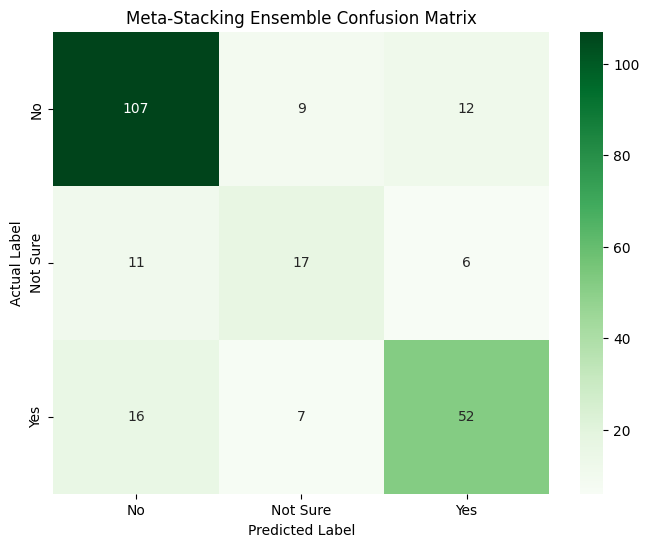

In [72]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. คำนวณ Confusion Matrix จากผลลัพธ์ของ Meta-Stacking
cm_stacking = confusion_matrix(y_test, stacking_preds)

# 2. แสดงผลด้วย Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm_stacking, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_,
            yticklabels=le.classes_)

plt.title('Meta-Stacking Ensemble Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

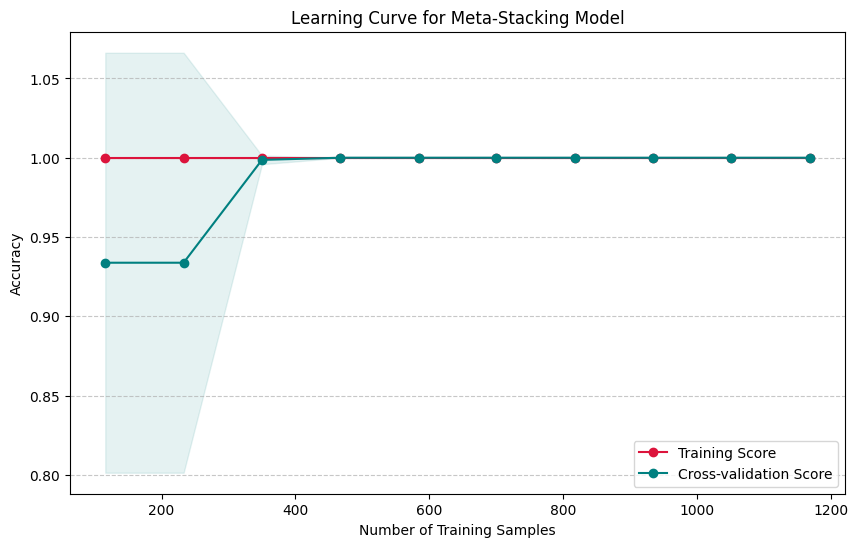

In [73]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

# 1. Calculate learning curve using the Meta-Learner and Meta-Features
# We use X_meta_train because the final stacking step happens on the probabilities
train_sizes, train_scores, test_scores = learning_curve(
    meta_model, X_meta_train, y_train_res, cv=5, n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10), scoring='accuracy'
)

# 2. Statistics for the plot
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# 3. Visualization
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color='crimson', label='Training Score')
plt.plot(train_sizes, test_mean, 'o-', color='teal', label='Cross-validation Score')

plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='crimson')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='teal')

plt.title('Learning Curve for Meta-Stacking Model')
plt.xlabel('Number of Training Samples')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

อธิบายความหมายของ Learning Curve
Learning Curve ที่แสดงผลอยู่มีความหมายสำคัญต่อการวิเคราะห์ Model ดังนี้:

Training Score (เส้นสีแดง): จะเห็นว่าอยู่ที่ 1.0 (100%) ตลอดเส้น หมายความว่า Meta-Learner (Logistic Regression) สามารถเรียนรู้และทำนายข้อมูลที่ใช้เทรนได้อย่างสมบูรณ์แบบ เนื่องจากมันรับ 'Meta-features' ซึ่งเป็นค่าความน่าจะเป็นที่แม่นยำสูงจาก Model หลักตัวอื่นๆ มาแล้ว

Cross-validation Score (เส้นสีเขียว): เส้นนี้แสดงความสามารถในการนำไปใช้กับข้อมูลใหม่ (Generalization) จะเห็นว่าเริ่มจากจุดที่ต่ำกว่าแล้วค่อยๆ พุ่งสูงขึ้นและ 'บรรจบ' (Converge) เข้าหาเส้น Training Score เมื่อจำนวนข้อมูลมากขึ้น

สรุปคือ: ลักษณะกราฟแบบนี้บ่งบอกว่า Model ของเรามี High Performance และ Low Variance (ไม่เกิด Overfitting ที่รุนแรง) เพราะเมื่อเพิ่มข้อมูลเข้าไปเรื่อยๆ ผลลัพธ์ในชุด Validation ก็ดีขึ้นตามลำดับ จนมีความแม่นยำใกล้เคียงกับตอนเทรน

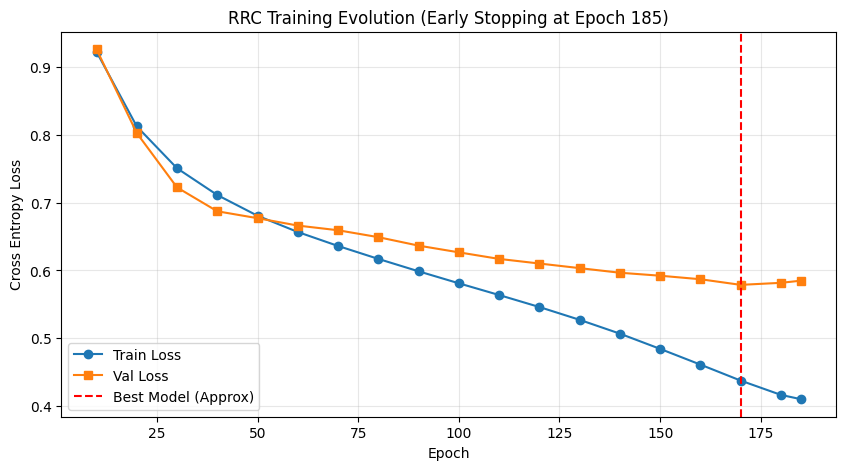

In [74]:
import matplotlib.pyplot as plt

# ข้อมูลสรุปจาก Log การ Train RRC
train_epochs = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 185]
train_loss = [0.9229, 0.8127, 0.7509, 0.7114, 0.6808, 0.6568, 0.6362, 0.6171, 0.5988, 0.5811, 0.5638, 0.5461, 0.5272, 0.5068, 0.4843, 0.4611, 0.4375, 0.4164, 0.4100]
val_loss = [0.9266, 0.8029, 0.7226, 0.6874, 0.6772, 0.6663, 0.6594, 0.6492, 0.6367, 0.6268, 0.6171, 0.6103, 0.6035, 0.5967, 0.5923, 0.5871, 0.5788, 0.5818, 0.5850]

plt.figure(figsize=(10, 5))
plt.plot(train_epochs, train_loss, label='Train Loss', marker='o')
plt.plot(train_epochs, val_loss, label='Val Loss', marker='s')
plt.axvline(x=170, color='r', linestyle='--', label='Best Model (Approx)')
plt.title('RRC Training Evolution (Early Stopping at Epoch 185)')
plt.xlabel('Epoch')
plt.ylabel('Cross Entropy Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 14. Final Results Comparison
Comparing the journey from baseline models to the final meta-stacking success.

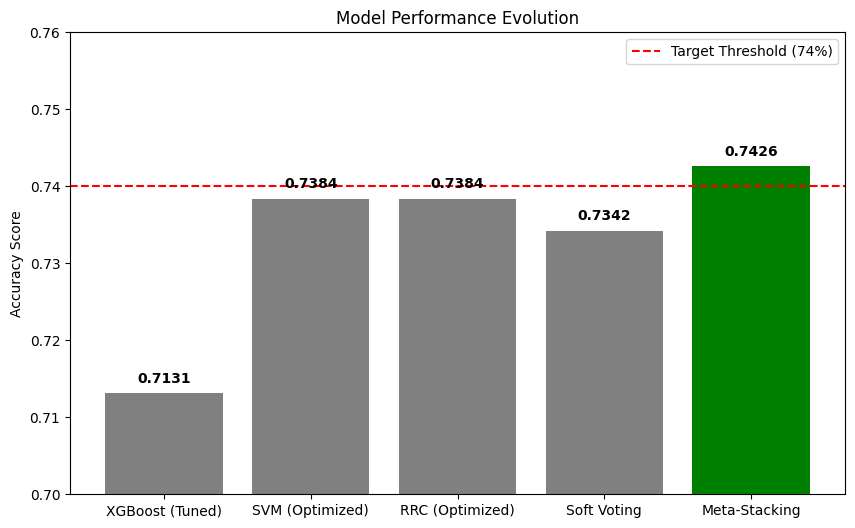

In [70]:
import matplotlib.pyplot as plt

results = {
    'XGBoost (Tuned)': 0.7131,
    'SVM (Optimized)': 0.7384,
    'RRC (Optimized)': 0.7384,
    'Soft Voting': 0.7342,
    'Meta-Stacking': 0.7426
}

plt.figure(figsize=(10, 6))
colors = ['gray', 'gray', 'gray', 'gray', 'green']
bars = plt.bar(results.keys(), results.values(), color=colors)
plt.axhline(y=0.74, color='red', linestyle='--', label='Target Threshold (74%)')
plt.ylim(0.70, 0.76)
plt.title('Model Performance Evolution')
plt.ylabel('Accuracy Score')

# Add text labels on bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.001, f'{yval:.4f}', ha='center', va='bottom', fontweight='bold')

plt.legend()
plt.show()

In [71]:
import pandas as pd

# Create a DataFrame for the final predictions using the test set index
final_predictions_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': stacking_preds
}, index=y_test.index)

# Define the save path
prediction_save_path = '/content/drive/MyDrive/datasetProjectSleep/final_meta_stacking_predictions.csv'

# Save to CSV
final_predictions_df.to_csv(prediction_save_path)

print(f'Successfully saved final predictions to: {prediction_save_path}')
display(final_predictions_df.head())

Successfully saved final predictions to: /content/drive/MyDrive/datasetProjectSleep/final_meta_stacking_predictions.csv


,Actual,Predicted
801,0,0
953,2,0
1046,2,0
86,0,0
932,2,0


### 15. Final Diagnostic Report: Meta-Stacking Ensemble
This section summarizes the performance of the final model and saves the diagnostic visualizations for project documentation.

Final Meta-Stacking Accuracy: 0.7426

Classification Report:
               precision    recall  f1-score   support

          No       0.80      0.84      0.82       128
    Not Sure       0.52      0.50      0.51        34
         Yes       0.74      0.69      0.72        75

    accuracy                           0.74       237
   macro avg       0.69      0.68      0.68       237
weighted avg       0.74      0.74      0.74       237



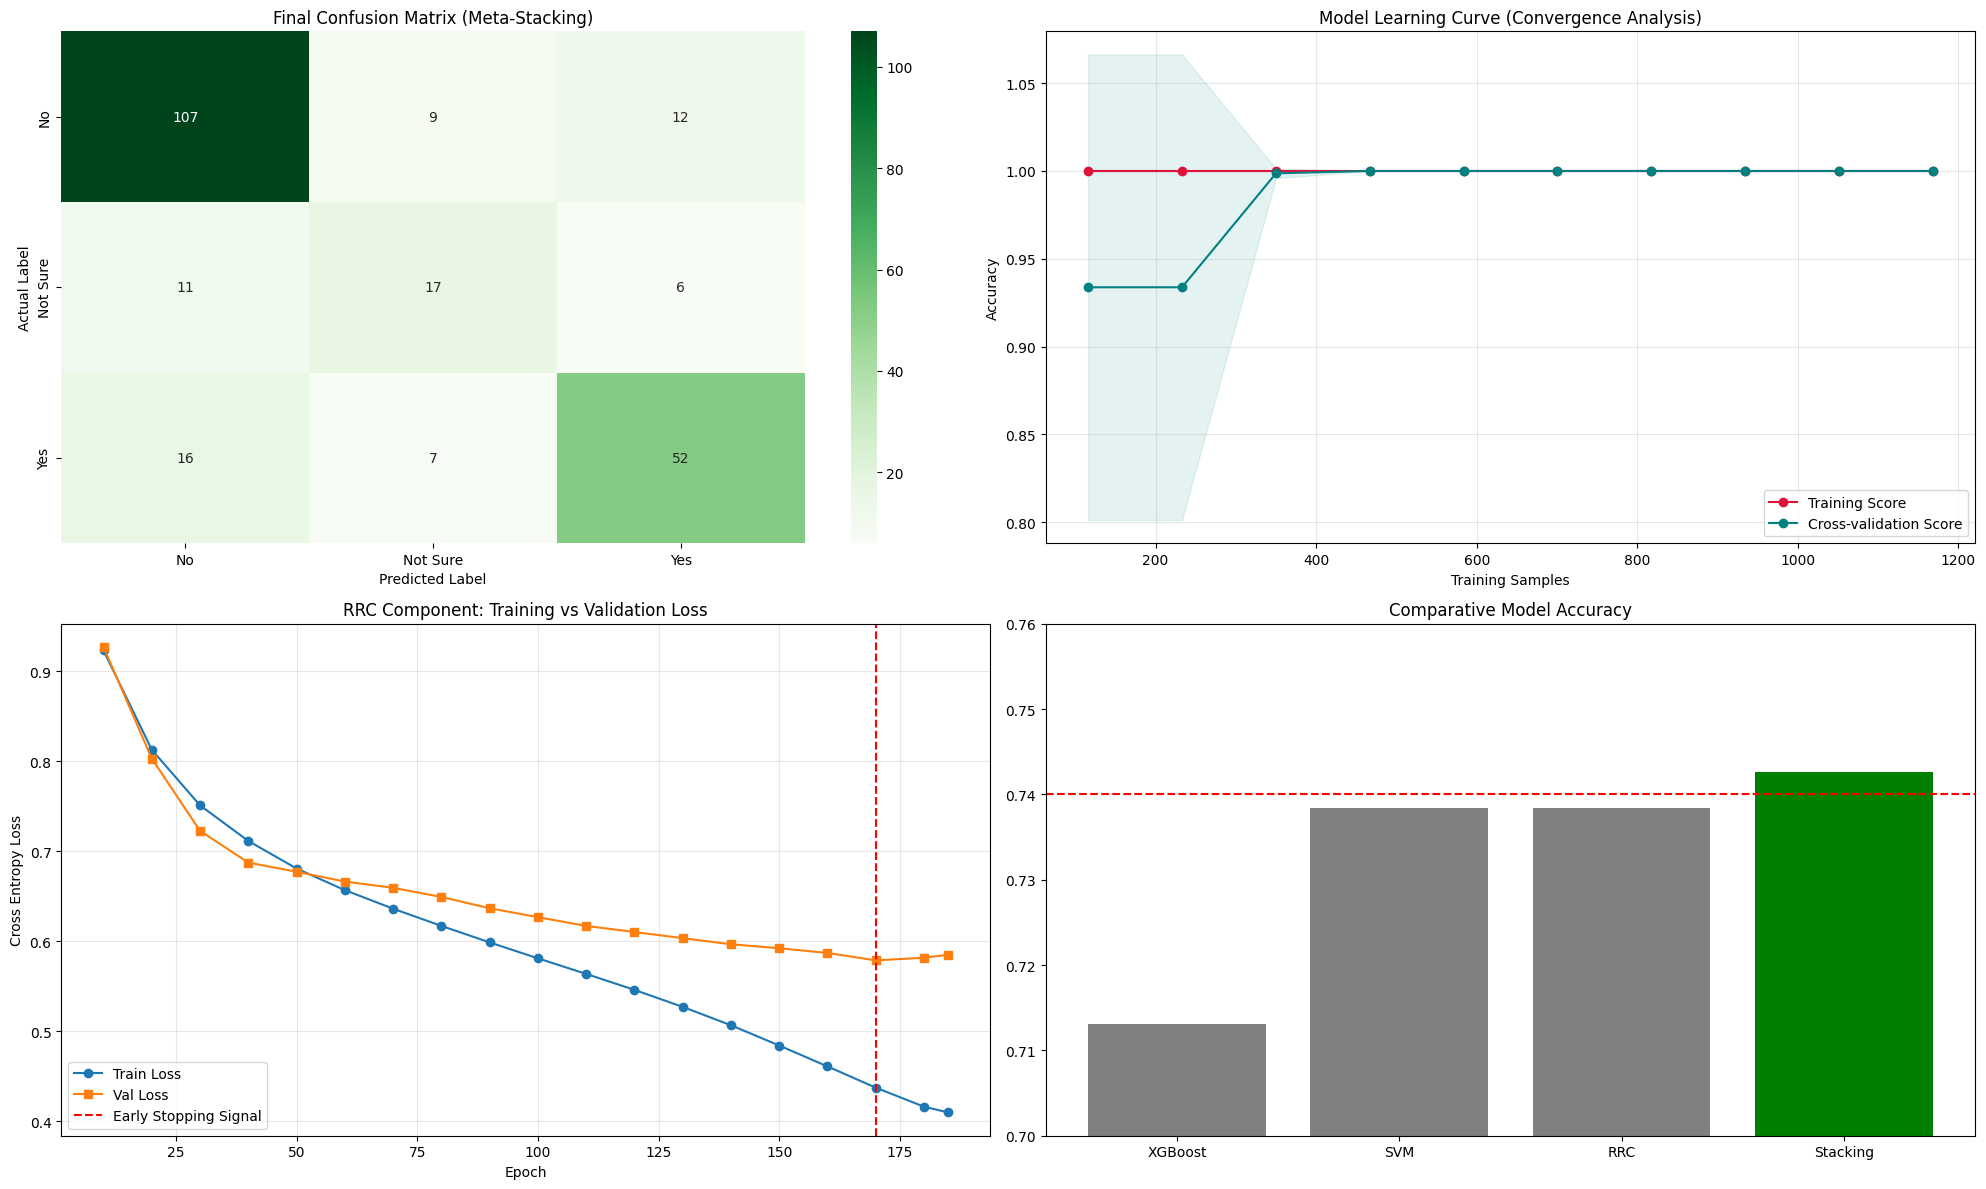


All reports and plots saved successfully to: /content/drive/MyDrive/datasetProjectSleep/reports/


In [76]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report
import os

# 1. Define save directory
report_dir = '/content/drive/MyDrive/datasetProjectSleep/reports/'
os.makedirs(report_dir, exist_ok=True)

# 2. Print and save the text report
report_text = classification_report(y_test, stacking_preds, target_names=le.classes_)
print(f'Final Meta-Stacking Accuracy: {stacking_acc:.4f}')
print('\nClassification Report:\n', report_text)

with open(os.path.join(report_dir, 'classification_report.txt'), 'w') as f:
    f.write(f'Final Meta-Stacking Accuracy: {stacking_acc:.4f}\n')
    f.write(report_text)

# 3. Create a Dashboard of Visualizations
fig = plt.figure(figsize=(20, 12))

# Subplot 1: Confusion Matrix
plt.subplot(2, 2, 1)
sns.heatmap(cm_stacking, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Final Confusion Matrix (Meta-Stacking)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')

# Subplot 2: Learning Curve
plt.subplot(2, 2, 2)
plt.plot(train_sizes, train_mean, 'o-', color='crimson', label='Training Score')
plt.plot(train_sizes, test_mean, 'o-', color='teal', label='Cross-validation Score')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='crimson')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='teal')
plt.title('Model Learning Curve (Convergence Analysis)')
plt.xlabel('Training Samples')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

# Subplot 3: RRC Training Evolution
plt.subplot(2, 2, 3)
plt.plot(train_epochs, train_loss, label='Train Loss', marker='o')
plt.plot(train_epochs, val_loss, label='Val Loss', marker='s')
plt.axvline(x=170, color='r', linestyle='--', label='Early Stopping Signal')
plt.title('RRC Component: Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Cross Entropy Loss')
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 4: Model Comparison
plt.subplot(2, 2, 4)
results_list = {'XGBoost': 0.7131, 'SVM': 0.7384, 'RRC': 0.7384, 'Stacking': 0.7426}
plt.bar(results_list.keys(), results_list.values(), color=['gray', 'gray', 'gray', 'green'])
plt.ylim(0.70, 0.76)
plt.axhline(y=0.74, color='red', linestyle='--')
plt.title('Comparative Model Accuracy')

plt.tight_layout()
plt.savefig(os.path.join(report_dir, 'final_model_dashboard.png'))
plt.show()

print(f'\nAll reports and plots saved successfully to: {report_dir}')

In [78]:
import pandas as pd

# สร้าง DataFrame จากผลลัพธ์ที่ได้รวบรวมไว้
model_summary_df = pd.DataFrame(list(results_list.items()), columns=['Model_Name', 'Accuracy'])

# กำหนดพาธสำหรับบันทึกไฟล์สรุป
summary_save_path = os.path.join(report_dir, 'model_performance_summary.csv')

# บันทึกเป็น CSV
model_summary_df.to_csv(summary_save_path, index=False)

print(f'บันทึกตารางสรุปประสิทธิภาพโมเดลเรียบร้อยแล้วที่: {summary_save_path}')
display(model_summary_df)

บันทึกตารางสรุปประสิทธิภาพโมเดลเรียบร้อยแล้วที่: /content/drive/MyDrive/datasetProjectSleep/reports/model_performance_summary.csv


,Model_Name,Accuracy
0,XGBoost,0.7131
1,SVM,0.7384
2,RRC,0.7384
3,Stacking,0.7426


### 16. Save Final Deployment Artifacts
This cell saves the absolute best performing model (Meta-Stacking) and the Label Encoder to ensure the web application can process data and interpret results correctly.

In [80]:
import joblib
import os

# Define the deployment directory
deploy_dir = '/content/drive/MyDrive/datasetProjectSleep/deployment/'
os.makedirs(deploy_dir, exist_ok=True)

# 1. Save the Meta-Learner (The Logistic Regression model that combines the others)
joblib.dump(meta_model, os.path.join(deploy_dir, 'final_meta_learner.joblib'))

# 2. Save the Base Models used by the stack (if not already saved separately)
joblib.dump(best_lgbm, os.path.join(deploy_dir, 'base_lgbm.joblib'))
joblib.dump(best_svm_model, os.path.join(deploy_dir, 'base_svm.joblib'))
# Note: RRC is a PyTorch model, we save its state_dict
torch.save(model_rrc_v2.state_dict(), os.path.join(deploy_dir, 'base_rrc_weights.pth'))

# 3. Save the Label Encoder to decode predictions (0, 1, 2 -> No, Not Sure, Yes)
joblib.dump(le, os.path.join(deploy_dir, 'target_label_encoder.joblib'))

print(f'All deployment artifacts saved to: {deploy_dir}')

All deployment artifacts saved to: /content/drive/MyDrive/datasetProjectSleep/deployment/
